# Paralelismo

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb) (postulado de determinação da reta; duas retas distintas têm no máximo um ponto em comum; teste de colinearidade), [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (ângulos opostos pelo vértice, complementares e suplementares, congruência de ângulos) e [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (a soma dos ângulos internos, verificada experimentalmente e que agora vai ser demonstrada; o teorema do ângulo externo).

**Objetivos de aprendizagem:** ao final você será capaz de...
- Reconhecer retas paralelas e enunciar o postulado das paralelas (a forma de Playfair do 5º postulado de Euclides).
- Identificar os ângulos formados por duas retas cortadas por uma transversal (correspondentes, alternos internos e externos, colaterais internos e externos) e usar suas relações de congruência e de suplementaridade.
- Demonstrar formalmente que a soma dos ângulos internos de um triângulo é 180°, traçando uma paralela a um dos lados.
- Aplicar as propriedades do paralelismo para encontrar ângulos desconhecidos em figuras.

**Tempo estimado:** 60 a 75 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0406a_paralelismo.ipynb)

## Uma dívida de dois notebooks atrás

Em [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) você mediu os ângulos de dezenas de triângulos sorteados, e a soma deu **sempre** 180°. Depois "recortou" os três cantos de um triângulo e viu que eles se encaixam lado a lado formando um **ângulo raso**. Convincente... mas **não é uma demonstração**. Medir mil triângulos não garante nada sobre o triângulo número mil e um, e um recorte de papel sempre tem um errinho de tesoura. Lá ficou uma promessa: a prova de verdade viria depois. Ela vem **aqui**.

A pista está no terceiro desenho logo abaixo: um triângulo e, passando pelo vértice de cima, uma reta tracejada que acompanha o lado de baixo sem nunca encostar nele. A pergunta que guia este notebook é:

> **o que uma reta paralela a um dos lados do triângulo tem a ver com a soma dos ângulos dar sempre 180°?**

Antes de responder, repare que "retas que nunca se encontram" estão por toda parte: os dois **trilhos** de uma ferrovia, as **linhas** de uma folha pautada, as bordas de uma régua, as faixas de uma rodovia. Por mais que se prolonguem, não se cruzam. E a margem vermelha do caderno, que corta todas as linhas da folha, esconde um padrão de ângulos que vai ser a chave da demonstração. Neste notebook você vai:
- dar um nome preciso a essa ideia e conhecer o **postulado** mais famoso (e mais polêmico) da história da matemática;
- descobrir que uma reta que corta duas paralelas cria **oito ângulos** com um padrão muito regular;
- usar esse padrão para, finalmente, **demonstrar** o 180°.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc, Polygon, Wedge

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Cores dos ângulos internos do 1º, 2º e 3º vértice, as mesmas de 0404a e 0405a:
# Â sempre azul-claro, B̂ sempre verde, Ĉ sempre lilás
CORES_VERTICES = (COR_PONTO, COR_DESTAQUE, COR_EXTRA)


def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def cruzamento(P, inclinacao_1: float, Q, inclinacao_2: float):
    """Ponto em que a reta que passa por P (com a inclinação `inclinacao_1`, em graus) cruza a reta
    que passa por Q (com a inclinação `inclinacao_2`). Devolve None se as duas retas tiverem a mesma
    direção, porque aí elas não se cruzam num ponto só.

    Por trás, é um sistema linear 2×2 (módulo 03): P + t·u = Q + k·v, com incógnitas t e k.
    """
    matriz = np.column_stack([direcao(inclinacao_1), -direcao(inclinacao_2)])
    if abs(np.linalg.det(matriz)) < 1e-12:
        return None
    t, _ = np.linalg.solve(matriz, np.subtract(Q, P))
    return np.array(P, dtype=float) + t * direcao(inclinacao_1)


def desenhar_ponto(ax, p, nome: str = "", cor: str = COR_AVISO, deslocamento=(0.12, 0.15)) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=7, zorder=5)
    if nome:
        ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")


def desenhar_reta(ax, ponto, inclinacao: float, cor: str = COR_SECUNDARIA, estilo: str = "-",
                  largura: float = 2.5, nome: str | None = None, posicao_nome=None) -> None:
    """Desenha a reta que passa por `ponto` com a inclinação dada (em graus). Uma reta é infinita:
    desenhamos um pedaço bem comprido e o próprio eixo corta o que sobra (por isso, chame
    `preparar_eixo` ANTES). O nome da reta (letra minúscula) vai em `posicao_nome`."""
    p = np.array(ponto, dtype=float)
    d = direcao(inclinacao)
    ax.plot(*zip(p - 100 * d, p + 100 * d), color=cor, lw=largura, linestyle=estilo)
    if nome and posicao_nome is not None:
        ax.text(*posicao_nome, nome, color=cor, fontsize=14, style="italic", fontweight="bold",
                ha="center", va="center")


def desenhar_setor(ax, vertice, inicio: float, abertura: float, raio: float = 0.5, cor: str = COR_PONTO,
                   rotulo: str | None = None, marcar_reto: bool = True, raio_rotulo: float | None = None,
                   tamanho_fonte: int = 11) -> None:
    """Pinta o ângulo com vértice em `vertice` que começa na direção `inicio` e gira `abertura`
    graus no sentido anti-horário. O ângulo reto ganha o quadradinho no lugar do arco."""
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90, abs_tol=1e-6):
        lado = 0.6 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        ax.add_patch(Arc(v, 2 * raio, 2 * raio, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia_rotulo = 1.6 * raio if raio_rotulo is None else raio_rotulo
        posicao = v + distancia_rotulo * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=tamanho_fonte, ha="center", va="center", fontweight="bold")


def desenhar_arco(ax, vertice, p, q, **opcoes) -> None:
    """Marca o ângulo de vértice `vertice` formado pelas semirretas que passam por p e por q
    (sempre a abertura menor, entre 0° e 180°). Aceita as mesmas opções de `desenhar_setor`."""
    inicio = direcao_de(vertice, p) % 360
    abertura = (direcao_de(vertice, q) - inicio) % 360
    if abertura > 180:
        inicio, abertura = direcao_de(vertice, q) % 360, 360 - abertura
    desenhar_setor(ax, vertice, inicio, abertura, **opcoes)

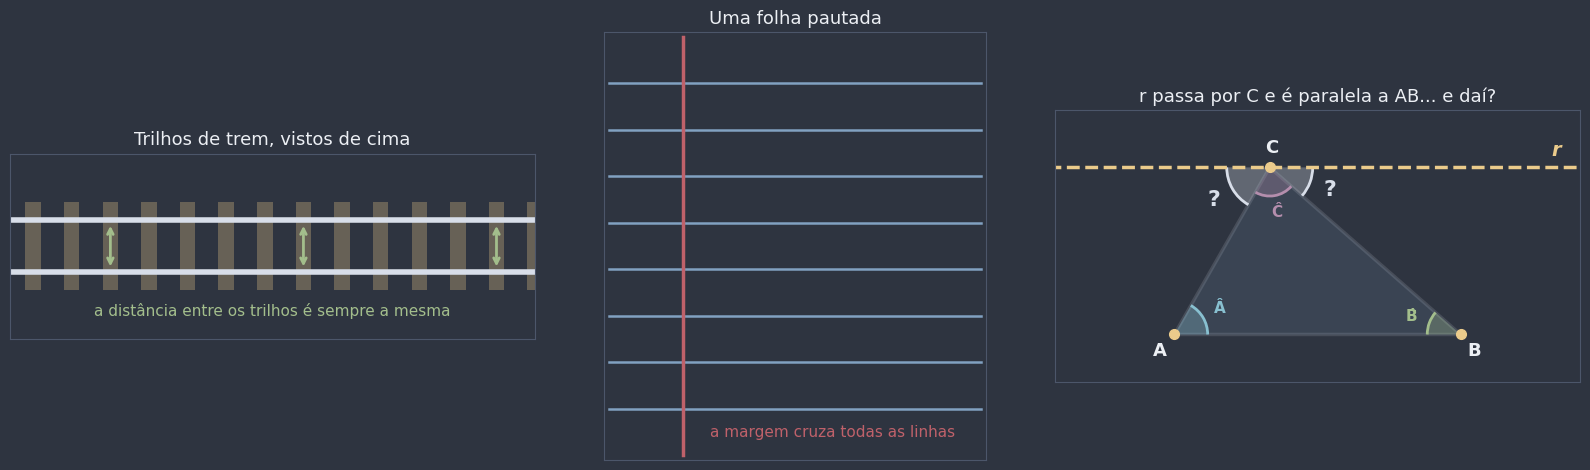

In [2]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)

# 1) Trilhos de trem vistos de cima: a distância entre eles (a bitola) nunca muda
preparar_eixo(ax1, [(0, -1.2), (10, 2.2)], margem=0.1)
for x in np.arange(0.2, 10, 0.75):
    ax1.add_patch(Polygon([(x, -0.35), (x + 0.3, -0.35), (x + 0.3, 1.35), (x, 1.35)], closed=True,
                          facecolor=COR_AVISO, alpha=0.3, edgecolor="none"))
for y in (0, 1):
    ax1.plot([-1, 11], [y, y], color=NORD_TEXTO_SEC, lw=4)
for x in (1.85, 5.6, 9.35):
    ax1.annotate("", xy=(x, 0.95), xytext=(x, 0.05),
                 arrowprops=dict(arrowstyle="<->", color=COR_DESTAQUE, lw=2))
ax1.text(5, -0.85, "a distância entre os trilhos é sempre a mesma", color=COR_DESTAQUE, fontsize=11,
         ha="center")
ax1.set_title("Trilhos de trem, vistos de cima", color=NORD_TEXTO, fontsize=13)

# 2) Folha pautada: linhas paralelas e a margem vermelha cortando todas elas
preparar_eixo(ax2, [(0, 0), (8, 9)], margem=0.1)
for y in range(1, 9):
    ax2.plot([0, 8], [y, y], color=COR_SECUNDARIA, lw=1.8)
ax2.plot([1.6, 1.6], [0, 9], color=COR_ALERTA, lw=2.5)
ax2.text(4.8, 0.4, "a margem cruza todas as linhas", color=COR_ALERTA, fontsize=11, ha="center")
ax2.set_title("Uma folha pautada", color=NORD_TEXTO, fontsize=13)

# 3) O triângulo e uma reta paralela a AB passando por C: o que ela tem a ver com o 180°?
A, B, C = np.array([0.0, 0.0]), np.array([6.0, 0.0]), np.array([2.0, 3.5])
preparar_eixo(ax3, [(-2.4, -0.9), (8.4, 4.6)], margem=0.1)
ax3.add_patch(Polygon([A, B, C], closed=True, facecolor=COR_SECUNDARIA, alpha=0.15, edgecolor=NORD_TEXTO_SEC,
                      lw=2.5))
desenhar_reta(ax3, C, 0, cor=COR_AVISO, estilo="--", nome="r", posicao_nome=(8.0, 3.85))
desenhar_arco(ax3, A, B, C, raio=0.7, cor=COR_PONTO, rotulo="Â", raio_rotulo=1.1)
desenhar_arco(ax3, B, C, A, raio=0.7, cor=COR_DESTAQUE, rotulo="B̂", raio_rotulo=1.1)
desenhar_arco(ax3, C, A, B, raio=0.6, cor=COR_EXTRA, rotulo="Ĉ", raio_rotulo=0.95)
desenhar_setor(ax3, C, 180, direcao_de(C, A) % 360 - 180, raio=0.9, cor=NORD_TEXTO_SEC, rotulo="?",
               raio_rotulo=1.35, tamanho_fonte=16)
desenhar_setor(ax3, C, direcao_de(C, B) % 360, 360 - direcao_de(C, B) % 360, raio=0.9, cor=NORD_TEXTO_SEC,
               rotulo="?", raio_rotulo=1.35, tamanho_fonte=16)
for P, nome, d in [(A, "A", (-0.45, -0.45)), (B, "B", (0.15, -0.45)), (C, "C", (-0.1, 0.3))]:
    desenhar_ponto(ax3, P, nome, deslocamento=d)
ax3.set_title("r passa por C e é paralela a AB... e daí?", color=NORD_TEXTO, fontsize=13)

plt.tight_layout()
plt.show()

Os três desenhos têm a mesma ideia escondida: retas que **mantêm a mesma direção** e, por isso, nunca se encontram. Na seção 1 vamos dar um nome preciso a elas; na seção 2, estudar o que acontece quando uma reta (como a margem do caderno) corta duas delas; e, na seção 3, descobrir o que são os dois pontos de interrogação do triângulo.

## 1. Retas paralelas e o postulado das paralelas

Em [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb) você viu um teorema: **duas retas distintas têm no máximo um ponto em comum**. Então, para duas retas de um mesmo plano, só existem três possibilidades:

| Posição relativa | Pontos em comum | Exemplo do dia a dia |
|---|---|---|
| **concorrentes** | exatamente **um** | duas ruas que se cruzam numa esquina |
| **paralelas distintas** | **nenhum** | os dois trilhos de uma ferrovia |
| **coincidentes** | **todos** (são a mesma reta) | uma linha da folha pautada riscada duas vezes com a caneta |

📌 **Definição formal (retas paralelas):** duas retas $r$ e $s$ são **paralelas** (notação $r \parallel s$) quando são **coincidentes** ou quando são **coplanares** (estão num mesmo plano) e **não têm ponto em comum**.

**A convenção deste curso.** Alguns livros chamam de paralelas só as retas **distintas** que não se encontram; outros (como a coleção *Fundamentos de Matemática Elementar*, de Dolce e Pompeo) incluem também as **coincidentes**. Aqui adotamos a segunda convenção: **toda reta é paralela a si mesma**. Ela tem uma vantagem que vai aparecer logo no postulado abaixo. Quando quisermos excluir o caso da mesma reta, diremos **paralelas distintas**; e, na seção 2, "duas paralelas cortadas por uma transversal" serão sempre paralelas distintas.

⚠️ **Erro comum:** esquecer a palavra **coplanares**. No espaço, duas retas podem não se encontrar **sem** ser paralelas: pense numa rua e num viaduto que passa por cima dela, atravessado. Essas retas são chamadas **reversas** e aparecem em Geometria Espacial (módulo 06). Neste notebook, todas as retas estão no mesmo plano.

No código, vamos descrever uma reta do jeito mais natural para a geometria: **um ponto** por onde ela passa e a sua **inclinação**, o ângulo (em graus) que ela faz com a horizontal. Duas retas com a **mesma inclinação** têm a mesma direção: não se cruzam num ponto só. Para decidir entre **distintas** e **coincidentes**, basta testar se um ponto de uma está na outra (o teste de colinearidade por multiplicação cruzada de 0401a). Repare num detalhe: inclinações de 30° e de 210° descrevem a **mesma** reta, percorrida no sentido contrário, então as inclinações são comparadas "a menos de 180°".

In [3]:
def mesma_inclinacao(inclinacao_1: float, inclinacao_2: float) -> bool:
    """True se as duas inclinações dão a mesma direção de reta (30° e 210° são a mesma direção)."""
    diferenca = (inclinacao_1 - inclinacao_2) % 180
    return math.isclose(diferenca, 0, abs_tol=1e-9) or math.isclose(diferenca, 180, abs_tol=1e-9)


def esta_na_reta(ponto, P, inclinacao: float) -> bool:
    """True se `ponto` está na reta que passa por P com a inclinação dada
    (teste de colinearidade por multiplicação cruzada, de 0401a)."""
    d = direcao(inclinacao)
    v = np.subtract(ponto, P)
    return math.isclose(v[0] * d[1] - v[1] * d[0], 0, abs_tol=1e-9)


def posicao_relativa(P, inclinacao_1: float, Q, inclinacao_2: float) -> str:
    """Posição relativa da reta r (por P, com inclinacao_1) e da reta s (por Q, com inclinacao_2)."""
    if not mesma_inclinacao(inclinacao_1, inclinacao_2):
        return "concorrentes"
    if esta_na_reta(Q, P, inclinacao_1):
        return "coincidentes"
    return "paralelas distintas"


exemplos_retas = [
    ((0, 0), 30, (0, 2), 30),
    ((0, 0), 30, (0, 2), 35),
    ((0, 0), 30, (3, math.sqrt(3)), 210),
    ((0, 0), 0, (5, -1), 90),
    ((0, 0), 0, (0, 0.001), 0),
]
linhas = []
for P, a1, Q, a2 in exemplos_retas:
    posicao = posicao_relativa(P, a1, Q, a2)
    X = cruzamento(P, a1, Q, a2)
    if posicao == "concorrentes":
        em_comum = f"um: ({X[0]:.2f}, {X[1]:.2f})"
    else:
        em_comum = "todos" if posicao == "coincidentes" else "nenhum"
    linhas.append({
        "reta r (ponto, inclinação)": f"({P[0]:g}, {P[1]:g}), {a1}°",
        "reta s (ponto, inclinação)": f"({Q[0]:g}, {Q[1]:.3g}), {a2}°",
        "posição relativa": posicao,
        "pontos em comum": em_comum,
        "r ∥ s?": "✅" if posicao != "concorrentes" else "❌",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

"reta r (ponto, inclinação)","reta s (ponto, inclinação)",posição relativa,pontos em comum,r ∥ s?
"(0, 0), 30°","(0, 2), 30°",paralelas distintas,nenhum,✅
"(0, 0), 30°","(0, 2), 35°",concorrentes,"um: (-16.28, -9.40)",❌
"(0, 0), 30°","(3, 1.73), 210°",coincidentes,todos,✅
"(0, 0), 0°","(5, -1), 90°",concorrentes,"um: (5.00, 0.00)",❌
"(0, 0), 0°","(0, 0.001), 0°",paralelas distintas,nenhum,✅


Repare em dois casos: na terceira linha, as inclinações 30° e 210° parecem diferentes, mas o ponto $(3, \sqrt{3})$ está em $r$ e a direção é a mesma: é **a mesma reta**. Na última, as retas estão a só 0,001 de distância uma da outra e mesmo assim **nunca** se tocam. Agora, a representação gráfica das três posições:

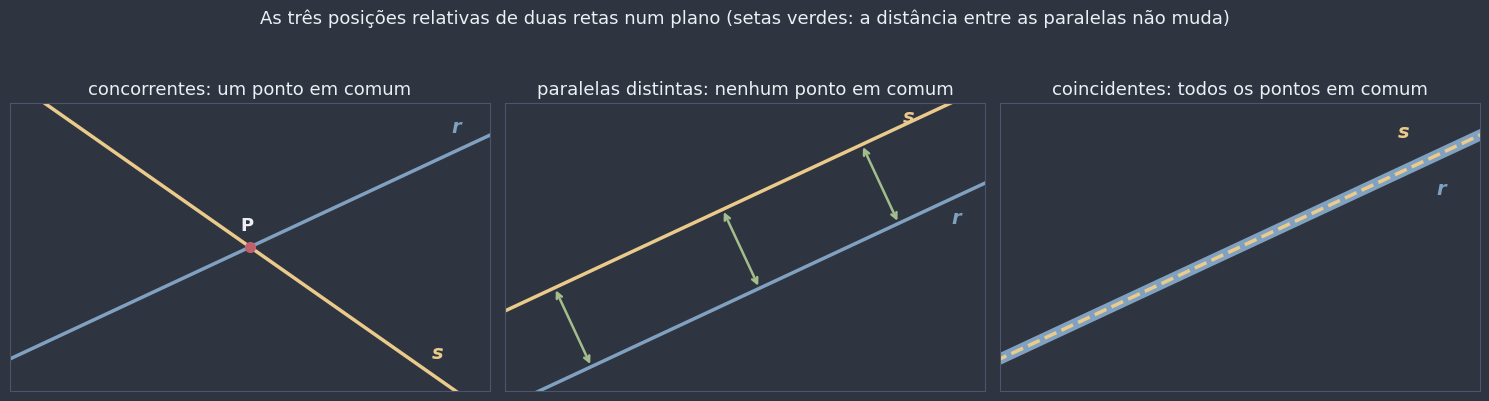

In [4]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4.6))
fig.patch.set_facecolor(NORD_FUNDO)
quadro = [(-5, -3), (5, 3)]

ax = eixos[0]
preparar_eixo(ax, quadro, margem=0)
desenhar_reta(ax, (0, 0), 25, cor=COR_SECUNDARIA, nome="r", posicao_nome=(4.3, 2.5))
desenhar_reta(ax, (0, 0), -35, cor=COR_AVISO, nome="s", posicao_nome=(3.9, -2.2))
desenhar_ponto(ax, (0, 0), "P", cor=COR_ALERTA, deslocamento=(-0.2, 0.35))
ax.set_title("concorrentes: um ponto em comum", color=NORD_TEXTO, fontsize=13)

ax = eixos[1]
preparar_eixo(ax, quadro, margem=0)
desenhar_reta(ax, (0, -1), 25, cor=COR_SECUNDARIA, nome="r", posicao_nome=(4.4, 0.6))
desenhar_reta(ax, (0, 1), 25, cor=COR_AVISO, nome="s", posicao_nome=(3.4, 2.9 - 0.2))
for x in (-3.2, 0.3, 3.2):
    base = np.array([x, -1 + x * math.tan(math.radians(25))])
    normal = direcao(115) * 2 * math.cos(math.radians(25))
    ax.annotate("", xy=base + normal, xytext=base, arrowprops=dict(arrowstyle="<->", color=COR_DESTAQUE, lw=1.8))
ax.set_title("paralelas distintas: nenhum ponto em comum", color=NORD_TEXTO, fontsize=13)

ax = eixos[2]
preparar_eixo(ax, quadro, margem=0)
desenhar_reta(ax, (0, 0), 25, cor=COR_SECUNDARIA, largura=8, nome="r", posicao_nome=(4.2, 1.2))
desenhar_reta(ax, (2, 2 * math.tan(math.radians(25))), 205, cor=COR_AVISO, estilo="--", largura=2.5,
              nome="s", posicao_nome=(3.4, 2.4))
ax.set_title("coincidentes: todos os pontos em comum", color=NORD_TEXTO, fontsize=13)

fig.suptitle("As três posições relativas de duas retas num plano (setas verdes: a distância entre as paralelas "
             "não muda)", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

### O postulado das paralelas

Pegue uma reta $r$ e um ponto $P$ **fora** dela. Quantas retas passando por $P$ são paralelas a $r$? Imagine uma régua presa em $P$ por um alfinete, girando: em quase todas as posições ela acaba cruzando $r$ (às vezes bem longe), e só numa posição ela nunca cruza. Intuitivo... mas aqui está o ponto surpreendente: **isso não se demonstra**. É aceito como **postulado** (uma proposição primitiva, como as de 0401a).

📌 **Postulado das paralelas (forma de Playfair):** por um ponto $P$ fora de uma reta $r$ passa **uma única** reta paralela a $r$.

Com a nossa convenção, se $P$ estiver **em** $r$, também existe uma única paralela a $r$ passando por $P$: a própria $r$ (qualquer outra reta por $P$ cruzaria $r$ justamente em $P$). Então dá para resumir tudo numa frase só: **por qualquer ponto do plano passa exatamente uma paralela a uma reta dada**. Essa é a vantagem da convenção.

**A representação numérica.** A reta $r$ é o eixo horizontal e $P = (0, 3)$. Vamos girar uma reta em torno de $P$, cada vez mais perto da horizontal, e calcular **onde** ela cruza $r$ (com a função `cruzamento`).

In [5]:
P = (0, 3)
linhas = []
for inclinacao in [30, 10, 5, 1, 0.1, 0.01, 0, -0.01, -1, -10]:
    X = cruzamento(P, inclinacao, (0, 0), 0)
    linhas.append({
        "inclinação da reta por P": f"{inclinacao:g}°",
        "cruza r em": "nunca cruza" if X is None else f"x = {X[0]:,.1f}",
        "distância de P até o cruzamento": "—" if X is None else f"{math.dist(P, X):,.1f}",
    })
print("r: eixo horizontal (inclinação 0°);  P = (0, 3)\n")
display(pd.DataFrame(linhas).style.hide(axis="index"))

r: eixo horizontal (inclinação 0°);  P = (0, 3)



inclinação da reta por P,cruza r em,distância de P até o cruzamento
30°,x = -5.2,6.0
10°,x = -17.0,17.3
5°,x = -34.3,34.4
1°,x = -171.9,171.9
0.1°,"x = -1,718.9","1,718.9"
0.01°,"x = -17,188.7","17,188.7"
0°,nunca cruza,—
-0.01°,"x = 17,188.7","17,188.7"
-1°,x = 171.9,171.9
-10°,x = 17.0,17.3


Quanto mais perto de 0°, mais **longe** fica o cruzamento: com 0,01° a reta só encontra $r$ a mais de 17 mil unidades de distância. Mas encontra! Qualquer inclinação diferente de 0°, por menor que seja, para um lado ou para o outro, produz um cruzamento. **Só uma** inclinação escapa: exatamente 0°, a da própria $r$.

🕹️ **Widget interativo:** a reta $r$ (horizontal) está fixa. O slider `inclinação` gira uma reta em torno de $P$, e o slider `altura de P` sobe e desce o ponto. Procure a posição em que a reta **nunca** cruza $r$ e confira que existe uma **só**, qualquer que seja a altura de $P$. Depois leve a altura a **0**: $P$ fica **sobre** $r$, e a única paralela passa a ser a própria $r$.

In [ ]:
def explorar_postulado(inclinacao: int, altura: float) -> None:
    P = np.array([0.0, altura])
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-10, -3.5), (10, 5.5)], margem=0)
    desenhar_reta(ax, (0, 0), 0, cor=COR_SECUNDARIA, largura=3.5, nome="r", posicao_nome=(9.4, -0.5))
    X = cruzamento(P, inclinacao, (0, 0), 0)
    if X is None:
        cor = COR_DESTAQUE
        titulo = ("P está em r: a única paralela a r por P é a própria r (coincidentes)" if altura == 0
                  else "inclinação 0°: esta reta NUNCA cruza r → é a paralela a r por P (e é única)")
    else:
        cor = COR_ALERTA
        if abs(X[0]) <= 9.5:
            ax.plot(*X, "X", color=COR_ALERTA, markersize=14, zorder=6)
            ax.text(X[0], X[1] - 0.8, f"cruza r em x = {X[0]:.1f}", color=COR_ALERTA, fontsize=11, ha="center")
        else:
            lado = 1 if X[0] > 0 else -1
            ax.annotate("", xy=(9.8 * lado, -1.6), xytext=(6.8 * lado, -1.6),
                        arrowprops=dict(arrowstyle="-|>", color=COR_ALERTA, lw=2))
            ax.text(8.3 * lado, -2.4, f"cruza lá longe,\nem x = {X[0]:,.0f}", color=COR_ALERTA, fontsize=11,
                    ha="center")
        titulo = f"inclinação {inclinacao}°: a reta cruza r — não é paralela"
    desenhar_reta(ax, P, inclinacao, cor=cor, largura=2.5)
    desenhar_ponto(ax, P, "P", deslocamento=(-0.6, 0.3))
    ax.set_title(titulo, color=cor, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_postulado,
    inclinacao=widgets.IntSlider(value=12, min=-60, max=60, step=1, description="inclinação (°):"),
    altura=widgets.FloatSlider(value=3, min=0, max=4.5, step=0.5, description="altura de P:"),
);

interactive(children=(IntSlider(value=12, description='inclinação (°):', max=60, min=-60), FloatSlider(value=3…

🕵️ **Curiosidade histórica — o postulado que resistiu por 2000 anos:** nos *Elementos* (por volta de 300 a.C.), Euclides escreveu o seu **5º postulado** de um jeito bem mais complicado: "se uma reta, cortando duas outras, forma ângulos internos de um mesmo lado com soma menor que dois ângulos retos, então essas duas retas, prolongadas indefinidamente, se encontram desse lado". A versão curta que usamos hoje foi popularizada pelo escocês **John Playfair**, em 1795, e as duas são **equivalentes**. Perto dos outros quatro postulados (como "por dois pontos passa uma reta"), o quinto parecia comprido demais para ser aceito sem prova, e por mais de **2000 anos** matemáticos como Ptolomeu, Ibn al-Haytham, Omar Khayyam e Saccheri tentaram **demonstrá-lo** a partir dos outros quatro. Todos falharam, e no século XIX descobriu-se o porquê: **não dá**. Gauss, **Lobachevsky** e **Bolyai** mostraram que existe uma geometria perfeitamente coerente em que, por um ponto fora de uma reta, passam **infinitas** paralelas (a geometria **hiperbólica**); e **Riemann** estudou geometrias em que **não existe nenhuma** paralela, como a da superfície de uma esfera, onde quaisquer dois "círculos máximos" se cruzam. São as **geometrias não euclidianas**.

E aqui está a ligação com a nossa dívida: em [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) você viu, na esfera, um triângulo com **três ângulos retos** (270° no total). Sem o postulado das paralelas, o 180° deixa de valer: na geometria hiperbólica a soma dos ângulos de um triângulo é **menor** que 180°; na esférica, **maior**. É por isso que a demonstração da seção 3 **precisa** de uma reta paralela: é exatamente ali que o 5º postulado entra.

🎯 **Aplicação prática — infraestrutura:** a distância entre os trilhos de uma ferrovia (a **bitola**) precisa ser a mesma em todo o percurso; no Brasil, as mais comuns são a métrica (1,000 m) e a larga (1,600 m). Se os trilhos deixassem de ser paralelos por alguns centímetros, as rodas sairiam deles. O mesmo vale para as faixas de uma rodovia (a largura da pista não pode "afunilar" sem aviso) e para as prateleiras de uma estante (paralelas ao chão, senão os objetos escorregam). Curiosidade de quebra: numa foto, os trilhos **parecem** se encontrar no horizonte. É efeito da **perspectiva** (o que está longe aparece menor); a distância real entre eles nunca muda.

📖 **Leitura complementar:** [Retas paralelas](https://pt.wikipedia.org/wiki/Retas_paralelas) · [Postulado das paralelas](https://pt.wikipedia.org/wiki/Postulado_das_paralelas) · [Geometria não euclidiana](https://pt.wikipedia.org/wiki/Geometria_n%C3%A3o_euclidiana)

**Pergunta de checagem:** duas retas de um mesmo plano que **não** são paralelas necessariamente se cruzam? O que isso diz sobre as posições possíveis de duas retas num plano?

**Pergunta de checagem:** com a convenção deste curso, uma reta é paralela a si mesma. Por que, com essa convenção, dá para dizer que por **qualquer** ponto passa exatamente uma paralela a uma reta dada, esteja o ponto dentro ou fora dela?

## 2. Ângulos formados por duas retas e uma transversal

Uma reta que corta duas outras retas em dois pontos **diferentes** é chamada de **transversal** a elas (na folha pautada do gancho, a margem vermelha é uma transversal às linhas). Em cada cruzamento aparecem **quatro** ângulos, e você já conhece esse desenho de [`0403a_angulos.ipynb`](0403a_angulos.ipynb): duas retas concorrentes formam dois pares de ângulos **opostos pelo vértice** (o.p.v.), que são congruentes, e cada ângulo é **suplementar** aos dois vizinhos. Com dois cruzamentos, são **oito** ângulos.

Para conversar sobre eles, vamos numerar sempre do mesmo jeito. Em cada cruzamento, começamos pelo ângulo de **cima à direita** e seguimos no sentido **anti-horário**: **1, 2, 3, 4** no cruzamento da transversal $t$ com a reta $r$ (em cima) e **5, 6, 7, 8** no cruzamento com a reta $s$ (embaixo). Duas divisões do plano ajudam a dar nomes:

- **interno × externo:** a faixa **entre** $r$ e $s$ é a região **interna**; o que fica fora dela é a região **externa**. Os ângulos **3, 4, 5, 6** são **internos**; os ângulos **1, 2, 7, 8** são **externos**.
- **lados da transversal:** $t$ divide o plano em dois lados. Os ângulos **2, 3, 6, 7** estão à **esquerda** de $t$; os ângulos **1, 4, 5, 8**, à **direita**.

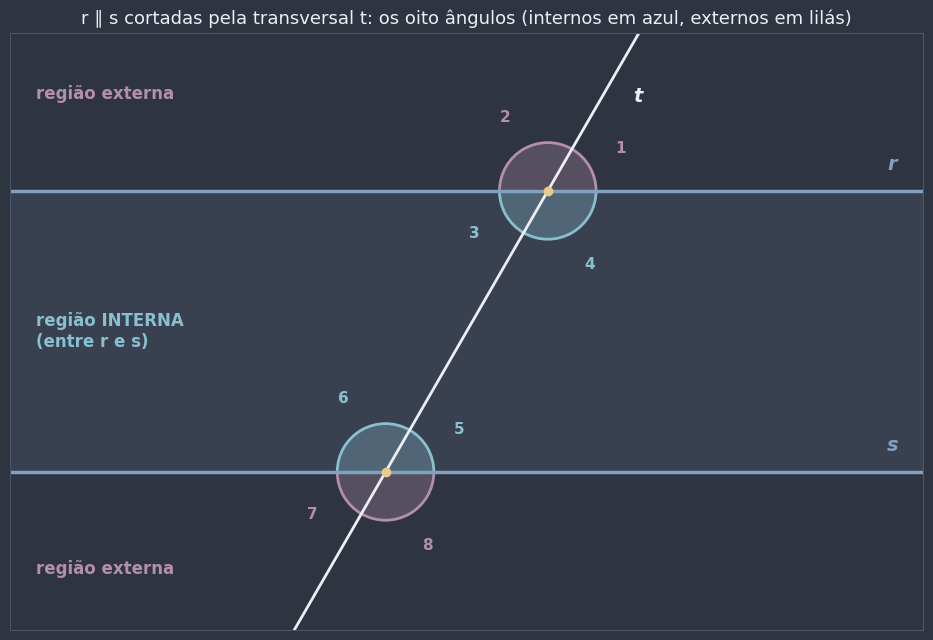

In [7]:
# As três retas da seção: r passa por PONTO_R, s por PONTO_S e a transversal t por PONTO_T
PONTO_R = np.array([0.0, 1.6])
PONTO_S = np.array([0.0, -1.6])
PONTO_T = np.array([0.0, 0.0])
QUADRO = [(-5.2, -3.4), (5.2, 3.4)]
# Cores usadas para diferenciar os pares de uma mesma família
CORES_PARES = (COR_PONTO, COR_DESTAQUE, COR_AVISO, COR_EXTRA)


def cruzamentos(inclinacao_t: float, inclinacao_s: float = 0.0) -> tuple[np.ndarray, np.ndarray]:
    """Os pontos em que t cruza r (horizontal) e em que t cruza s."""
    return (cruzamento(PONTO_R, 0, PONTO_T, inclinacao_t),
            cruzamento(PONTO_S, inclinacao_s, PONTO_T, inclinacao_t))


def medir_oito_angulos(inclinacao_t: float, inclinacao_s: float = 0.0) -> dict[int, float]:
    """Mede, com o transferidor digital, os oito ângulos formados por t com r e com s.

    Em cada cruzamento: 1 (ou 5) entre a reta, para a direita, e t, para cima; 2 (ou 6) entre t,
    para cima, e a reta, para a esquerda; 3 (ou 7) e 4 (ou 8) continuam no sentido anti-horário.
    """
    medidas = {}
    for base, X, inclinacao in zip((0, 4), cruzamentos(inclinacao_t, inclinacao_s), (0.0, inclinacao_s)):
        direita, esquerda = X + direcao(inclinacao), X - direcao(inclinacao)
        cima, baixo = X + direcao(inclinacao_t), X - direcao(inclinacao_t)
        medidas[base + 1] = medir_angulo(X, direita, cima)
        medidas[base + 2] = medir_angulo(X, cima, esquerda)
        medidas[base + 3] = medir_angulo(X, esquerda, baixo)
        medidas[base + 4] = medir_angulo(X, baixo, direita)
    return medidas


def desenhar_transversal(ax, inclinacao_t: float, inclinacao_s: float = 0.0, destaque=None,
                         rotulos: str = "numeros", raio: float = 0.5) -> dict[int, float]:
    """Desenha r, s e a transversal t com os oito ângulos e devolve as oito medidas.

    `destaque` = {número do ângulo: cor}: só esses ângulos são pintados (os outros ficam só com o
    número, apagadinho). `rotulos` = "numeros", "medidas" ou "ambos".
    """
    preparar_eixo(ax, QUADRO, margem=0)
    X, Y = cruzamentos(inclinacao_t, inclinacao_s)
    # Região interna: a faixa entre r e s
    xs = (QUADRO[0][0] - 1, QUADRO[1][0] + 1)
    altura_s = [PONTO_S[1] + x * math.tan(math.radians(inclinacao_s)) for x in xs]
    ax.add_patch(Polygon([(xs[0], PONTO_R[1]), (xs[1], PONTO_R[1]), (xs[1], altura_s[1]), (xs[0], altura_s[0])],
                         closed=True, facecolor=NORD_PAINEL, alpha=0.9, edgecolor="none", zorder=0))
    fim_x = QUADRO[1][0] - 0.35
    desenhar_reta(ax, PONTO_R, 0, cor=COR_SECUNDARIA, nome="r", posicao_nome=(fim_x, PONTO_R[1] + 0.3))
    desenhar_reta(ax, PONTO_S, inclinacao_s, cor=COR_SECUNDARIA, nome="s",
                  posicao_nome=(fim_x, PONTO_S[1] + fim_x * math.tan(math.radians(inclinacao_s)) + 0.3))
    desenhar_reta(ax, PONTO_T, inclinacao_t, cor=NORD_TEXTO, largura=2, nome="t",
                  posicao_nome=PONTO_T + 2.85 / math.sin(math.radians(inclinacao_t)) * direcao(inclinacao_t)
                  + 0.35 * direcao(inclinacao_t - 90))
    medidas = medir_oito_angulos(inclinacao_t, inclinacao_s)
    for n in range(1, 9):
        vertice, inclinacao = (X, 0.0) if n <= 4 else (Y, inclinacao_s)
        inicio = [inclinacao, inclinacao_t, inclinacao + 180, inclinacao_t + 180][(n - 1) % 4]
        texto = {"numeros": f"{n}", "medidas": f"{medidas[n]:.0f}°",
                 "ambos": f"{n}\n{medidas[n]:.0f}°"}[rotulos]
        distancia_rotulo = raio * (2.3 if rotulos == "ambos" else 1.75)
        if destaque is None or n in destaque:
            cor = COR_SECUNDARIA if destaque is None else destaque[n]
            desenhar_setor(ax, vertice, inicio, medidas[n], raio=raio, cor=cor, rotulo=texto,
                           raio_rotulo=distancia_rotulo, tamanho_fonte=11)
        else:
            posicao = vertice + distancia_rotulo * direcao(inicio + medidas[n] / 2)
            ax.text(*posicao, f"{n}", color=NORD_LINHA, fontsize=11, ha="center", va="center", fontweight="bold")
    for P in (X, Y):
        ax.plot(*P, "o", color=COR_AVISO, markersize=6, zorder=5)
    return medidas


fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor(NORD_FUNDO)
internos_externos = {n: (COR_PONTO if n in (3, 4, 5, 6) else COR_EXTRA) for n in range(1, 9)}
desenhar_transversal(ax, 60, destaque=internos_externos, raio=0.55)
ax.text(-4.9, 0, "região INTERNA\n(entre r e s)", color=COR_PONTO, fontsize=12, va="center", fontweight="bold")
ax.text(-4.9, 2.7, "região externa", color=COR_EXTRA, fontsize=12, va="center", fontweight="bold")
ax.text(-4.9, -2.7, "região externa", color=COR_EXTRA, fontsize=12, va="center", fontweight="bold")
ax.set_title("r ∥ s cortadas pela transversal t: os oito ângulos (internos em azul, externos em lilás)",
             color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

Com essas duas divisões, os pares de ângulos (um de cada cruzamento) ganham nomes:

| Nome | Como reconhecer | Pares | Se $r \parallel s$ |
|---|---|---|---|
| **correspondentes** | ocupam a **mesma posição** em cada cruzamento | 1 e 5, 2 e 6, 3 e 7, 4 e 8 | congruentes |
| **alternos internos** | internos, em lados **opostos** da transversal | 3 e 5, 4 e 6 | congruentes |
| **alternos externos** | externos, em lados **opostos** da transversal | 1 e 7, 2 e 8 | congruentes |
| **colaterais internos** | internos, do **mesmo lado** da transversal | 3 e 6, 4 e 5 | suplementares |
| **colaterais externos** | externos, do **mesmo lado** da transversal | 1 e 8, 2 e 7 | suplementares |

E, dentro de um mesmo cruzamento, continuam valendo os pares de [`0403a_angulos.ipynb`](0403a_angulos.ipynb): **opostos pelo vértice** (1 e 3, 2 e 4, 5 e 7, 6 e 8), sempre congruentes, e **adjacentes** que formam um ângulo raso (como 1 e 2), sempre suplementares.

Os nomes contam a história: **alternos** vêm de **alternar** o lado da transversal; **colaterais** (co + lateral) estão do **mesmo lado**. Os colaterais também são chamados de **conjugados** em alguns livros.

💡 **Dica — as letras escondidas:** os correspondentes desenham um **F** (a transversal é a haste e as duas paralelas são os braços); os alternos internos desenham um **Z** (ou um **N**); os colaterais internos desenham um **U** (ou um **C**). Procurar essas letras na figura é um jeito rápido de reconhecer os pares.

Nos seis painéis abaixo, cada família aparece sozinha, com uma cor por par:

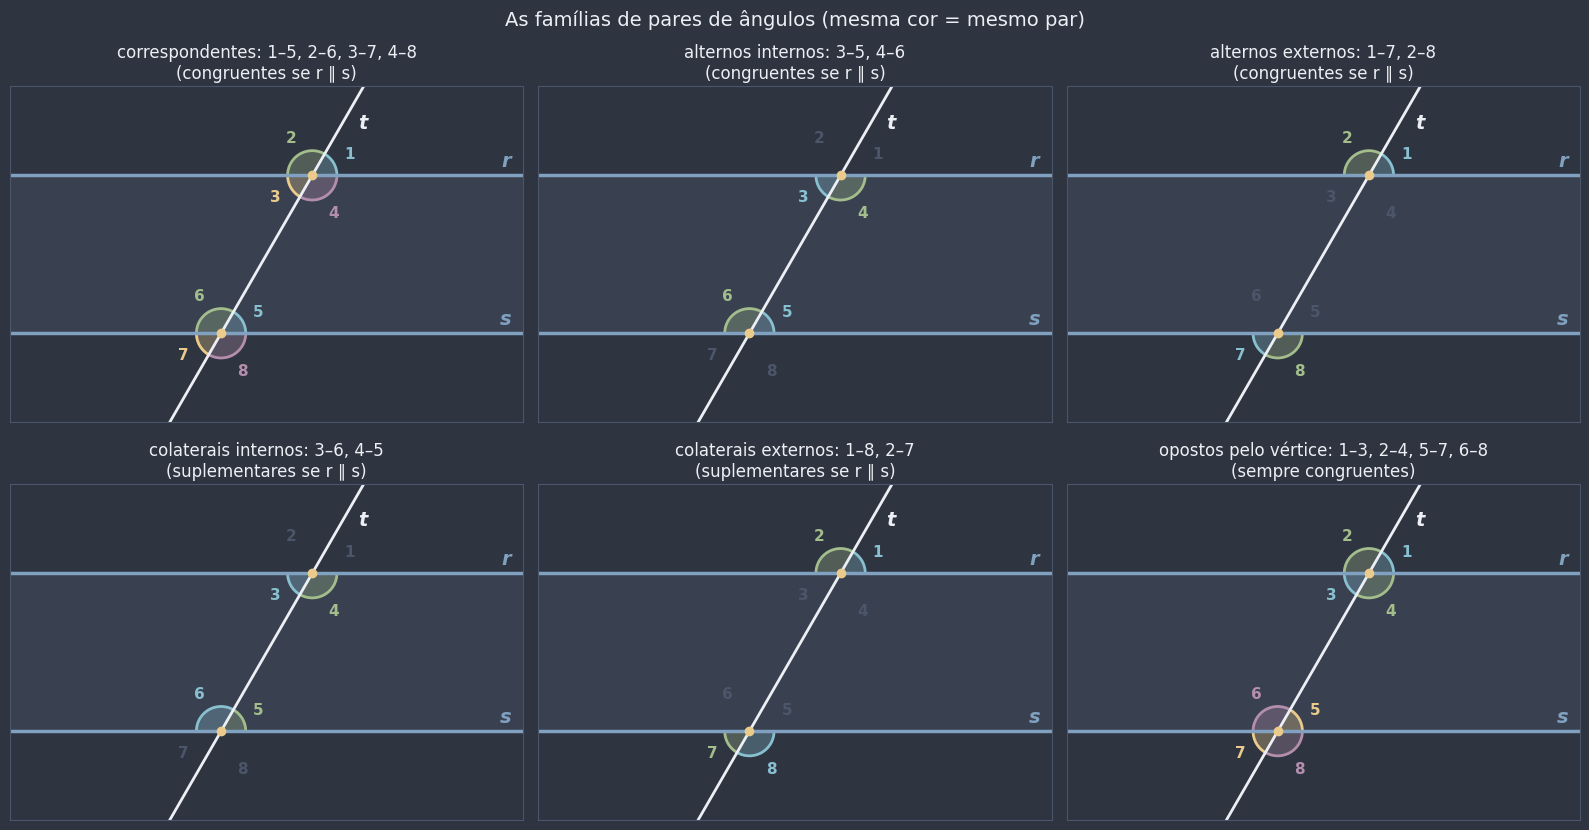

Alguns pares classificados pela função classificar_par:
  ângulos 1 e 5: correspondentes
  ângulos 4 e 6: alternos internos
  ângulos 2 e 8: alternos externos
  ângulos 3 e 6: colaterais internos
  ângulos 2 e 7: colaterais externos
  ângulos 5 e 7: opostos pelo vértice
  ângulos 1 e 2: adjacentes suplementares
  ângulos 1 e 6: sem nome especial


In [8]:
FAMILIAS = {
    "correspondentes": ([(1, 5), (2, 6), (3, 7), (4, 8)], "congruentes"),
    "alternos internos": ([(3, 5), (4, 6)], "congruentes"),
    "alternos externos": ([(1, 7), (2, 8)], "congruentes"),
    "colaterais internos": ([(3, 6), (4, 5)], "suplementares"),
    "colaterais externos": ([(1, 8), (2, 7)], "suplementares"),
    "opostos pelo vértice": ([(1, 3), (2, 4), (5, 7), (6, 8)], "congruentes"),
}


def classificar_par(i: int, j: int) -> str:
    """Nome do par de ângulos (i, j) na numeração padrão da seção 2."""
    par = tuple(sorted((i, j)))
    for nome, (pares, _) in FAMILIAS.items():
        if par in pares:
            return nome
    if (par[0] - 1) // 4 == (par[1] - 1) // 4:
        return "adjacentes suplementares"
    return "sem nome especial"


def destaque_da_familia(nome: str) -> dict[int, str]:
    """Pinta cada par da família com uma cor (os dois ângulos do par com a MESMA cor)."""
    pares, _ = FAMILIAS[nome]
    return {n: cor for par, cor in zip(pares, CORES_PARES) for n in par}


fig, eixos = plt.subplots(2, 3, figsize=(16, 8.8))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (nome, (pares, relacao)) in zip(eixos.flat, FAMILIAS.items()):
    desenhar_transversal(ax, 60, destaque=destaque_da_familia(nome))
    lista = ", ".join(f"{i}–{j}" for i, j in pares)
    quando = "sempre congruentes" if nome == "opostos pelo vértice" else f"{relacao} se r ∥ s"
    ax.set_title(f"{nome}: {lista}\n({quando})", color=NORD_TEXTO, fontsize=12)
fig.suptitle("As famílias de pares de ângulos (mesma cor = mesmo par)", color=NORD_TEXTO, fontsize=14)
plt.tight_layout()
plt.show()

print("Alguns pares classificados pela função classificar_par:")
for i, j in [(1, 5), (4, 6), (2, 8), (3, 6), (2, 7), (5, 7), (1, 2), (1, 6)]:
    print(f"  ângulos {i} e {j}: {classificar_par(i, j)}")

### O que acontece com as medidas quando $r \parallel s$

Os nomes servem para qualquer par de retas. A mágica aparece quando $r$ e $s$ são **paralelas**. Vamos medir os oito ângulos com o transferidor digital, para uma transversal com inclinação de 65°, e conferir cada família.

In [9]:
def conferir_familias(medidas: dict[int, float], familias=None) -> pd.DataFrame:
    """Tabela com cada par de cada família, as duas medidas e se a relação esperada (quando r ∥ s) vale."""
    linhas = []
    for nome in familias or FAMILIAS:
        pares, relacao = FAMILIAS[nome]
        for i, j in pares:
            m1, m2 = medidas[i], medidas[j]
            vale = math.isclose(m1, m2, abs_tol=1e-6) if relacao == "congruentes" else math.isclose(m1 + m2, 180)
            linhas.append({
                "família": nome, "par": f"{i} e {j}", "medidas": f"{m1:.1f}° e {m2:.1f}°",
                "soma": f"{m1 + m2:.1f}°", "relação esperada (r ∥ s)": relacao, "vale aqui?": "✅" if vale else "❌",
            })
    return pd.DataFrame(linhas)


medidas = medir_oito_angulos(65)
tabela_oito = pd.DataFrame({
    "ângulo": list(medidas),
    "cruzamento": ["t com r"] * 4 + ["t com s"] * 4,
    "região": ["externa" if n in (1, 2, 7, 8) else "interna" for n in medidas],
    "lado de t": ["direita" if n in (1, 4, 5, 8) else "esquerda" for n in medidas],
    "medida": [f"{m:.1f}°" for m in medidas.values()],
})
print("Transversal com inclinação de 65°, r ∥ s:\n")
display(tabela_oito.style.hide(axis="index"))
display(conferir_familias(medidas).style.hide(axis="index"))

Transversal com inclinação de 65°, r ∥ s:



ângulo,cruzamento,região,lado de t,medida
1,t com r,externa,direita,65.0°
2,t com r,externa,esquerda,115.0°
3,t com r,interna,esquerda,65.0°
4,t com r,interna,direita,115.0°
5,t com s,interna,direita,65.0°
6,t com s,interna,esquerda,115.0°
7,t com s,externa,esquerda,65.0°
8,t com s,externa,direita,115.0°


família,par,medidas,soma,relação esperada (r ∥ s),vale aqui?
correspondentes,1 e 5,65.0° e 65.0°,130.0°,congruentes,✅
correspondentes,2 e 6,115.0° e 115.0°,230.0°,congruentes,✅
correspondentes,3 e 7,65.0° e 65.0°,130.0°,congruentes,✅
correspondentes,4 e 8,115.0° e 115.0°,230.0°,congruentes,✅
alternos internos,3 e 5,65.0° e 65.0°,130.0°,congruentes,✅
alternos internos,4 e 6,115.0° e 115.0°,230.0°,congruentes,✅
alternos externos,1 e 7,65.0° e 65.0°,130.0°,congruentes,✅
alternos externos,2 e 8,115.0° e 115.0°,230.0°,congruentes,✅
colaterais internos,3 e 6,65.0° e 115.0°,180.0°,suplementares,✅
colaterais internos,4 e 5,115.0° e 65.0°,180.0°,suplementares,✅


Todas as relações da tabela valem. E repare numa simplificação enorme: dos oito ângulos, só aparecem **duas** medidas, 65° e 115°. Os ângulos **ímpares** (1, 3, 5, 7) medem $\alpha$ e os **pares** (2, 4, 6, 8) medem $180^\circ - \alpha$.

📌 **Propriedade fundamental dos correspondentes:** se $r \parallel s$ (distintas) e $t$ é uma transversal, então os ângulos **correspondentes** são congruentes.

Por que acreditar nela? Imagine o cruzamento de $t$ com $r$ **deslizando** ao longo de $t$, sem girar, até chegar em $s$. Como $r$ e $s$ têm a **mesma direção**, o "X" formado por $r$ e $t$ cai **exatamente** sobre o "X" formado por $s$ e $t$: o ângulo 1 cai sobre o 5, o 2 sobre o 6, e assim por diante. Formalmente, essa propriedade é **equivalente** ao postulado das paralelas: nos *Elementos*, a Proposição 29 do Livro I, que trata justamente desses ângulos, é a **primeira** em que Euclides usa o 5º postulado.

A partir dela, todo o resto é **demonstrado**, usando só o que você já sabe de [`0403a_angulos.ipynb`](0403a_angulos.ipynb). Por exemplo, para os alternos internos 3 e 5 e para os colaterais internos 4 e 5:

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | ângulo 3 ≡ ângulo 1 | opostos pelo vértice (0403a) |
| 2 | ângulo 1 ≡ ângulo 5 | correspondentes, com $r \parallel s$ |
| 3 | **ângulo 3 ≡ ângulo 5** (alternos internos) | passos 1 e 2 (dois ângulos congruentes a um terceiro são congruentes entre si) ∎ |
| 4 | ângulo 4 + ângulo 1 = 180° | adjacentes que formam um ângulo raso: suplementares (0403a) |
| 5 | **ângulo 4 + ângulo 5 = 180°** (colaterais internos) | trocando o ângulo 1 pelo ângulo 5 no passo 4, pelo passo 2 ∎ |

Os alternos e colaterais **externos** saem do mesmo jeito, trocando os ângulos internos pelos seus opostos pelo vértice.

📌 **Recíproca (a "volta"):** se uma transversal forma com $r$ e $s$ um par de ângulos **correspondentes congruentes** (ou **alternos congruentes**, ou **colaterais suplementares**), então $r \parallel s$.

Por quê? Suponha que os correspondentes 1 e 5 sejam congruentes, e chame de $Y$ o cruzamento de $t$ com $s$. Pelo postulado, por $Y$ passa **uma única** paralela $s'$ a $r$. Pela propriedade de ida, $s'$ forma com $t$ um ângulo correspondente ao 1, ou seja, **igual** ao ângulo 1, que é igual ao ângulo 5. Então $s$ e $s'$ saem de $Y$ formando com $t$ o **mesmo** ângulo, do **mesmo** lado: só podem ser a mesma reta. Logo $s = s' \parallel r$. (Os outros casos se reduzem a este usando o.p.v. e suplementos.)

A recíproca é um **teste de paralelismo**: para saber se duas retas são paralelas, não é preciso prolongá-las até o infinito, basta medir **dois ângulos** com uma transversal.

🕹️ **Widget interativo:** o slider `transversal` muda a inclinação de $t$, e o menu `destacar` escolhe a família de pares. Primeiro mexa **só na transversal**: com $r \parallel s$, todas as relações continuam valendo, qualquer que seja a inclinação. Depois mexa no slider `inclinação de s`, que **tira** o paralelismo, e veja na tabela quais relações quebram (e quais continuam valendo).

In [10]:
def explorar_transversal(inclinacao_t: int, inclinacao_s: int, destacar: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 6.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    destaque = None if destacar == "todos os oito" else destaque_da_familia(destacar)
    medidas = desenhar_transversal(ax, inclinacao_t, inclinacao_s, destaque=destaque, rotulos="ambos", raio=0.5)
    if inclinacao_s == 0:
        alfa = medidas[1]
        titulo = f"r ∥ s: só duas medidas aparecem, {alfa:.0f}° e {180 - alfa:.0f}°  ✓"
        cor = COR_DESTAQUE
    else:
        titulo = f"s inclinada {inclinacao_s}°: r e s NÃO são paralelas → as relações quebram  ✗"
        cor = COR_ALERTA
    ax.set_title(titulo, color=cor, fontsize=13)
    plt.tight_layout()
    plt.show()
    familias = None if destacar == "todos os oito" else [destacar]
    display(conferir_familias(medidas, familias).style.hide(axis="index"))


widgets.interact(
    explorar_transversal,
    inclinacao_t=widgets.IntSlider(value=60, min=35, max=145, step=5, description="transversal (°):"),
    inclinacao_s=widgets.IntSlider(value=0, min=-12, max=12, step=1, description="inclinação de s:"),
    destacar=widgets.Dropdown(options=["todos os oito", *FAMILIAS], value="alternos internos",
                              description="destacar:"),
);

interactive(children=(IntSlider(value=60, description='transversal (°):', max=145, min=35, step=5), IntSlider(…

⚠️ **Erro comum:** usar as relações de congruência e de suplementaridade quando as retas cortadas **não são paralelas**. Com $s$ inclinada, os nomes continuam os mesmos (o ângulo 3 e o ângulo 5 **continuam sendo** alternos internos), mas as medidas deixam de ter qualquer relação fixa entre si. Numa figura, **nunca** conclua "esses ângulos são iguais porque são alternos" sem antes ter certeza de que as retas são paralelas (o enunciado precisa dizer, ou a figura precisa ter a marca de paralelismo). Só duas relações sobrevivem sempre, porque acontecem dentro de um mesmo cruzamento: **opostos pelo vértice** são congruentes e ângulos **adjacentes** que formam um raso são suplementares.

📎 **Conexão:** no Exercício Desafio 5 de [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb), os ângulos $B\hat{A}C$ e $D\hat{C}A$ do paralelogramo saíram congruentes na medição. Agora dá para explicar **por quê**: $\overleftrightarrow{AB} \parallel \overleftrightarrow{DC}$ e a diagonal $\overleftrightarrow{AC}$ é uma transversal; os dois ângulos são **alternos internos**.

🎯 **Aplicação prática — mapas urbanos e design:** em muitas cidades planejadas, as ruas formam uma malha de paralelas cortada por avenidas em diagonal. Belo Horizonte, por exemplo, foi projetada no fim do século XIX pela comissão do engenheiro Aarão Reis com uma malha de ruas cortada por avenidas inclinadas. Quem anda por uma avenida dessas encontra, em **todos** os cruzamentos com as ruas paralelas, o **mesmo** ângulo: são ângulos correspondentes. O mesmo padrão aparece nas **grades de layout** usadas em design gráfico e em páginas da web, onde colunas paralelas são cortadas por guias transversais. Vamos conferir numa cidade de brinquedo, com quatro ruas paralelas e duas avenidas paralelas entre si.

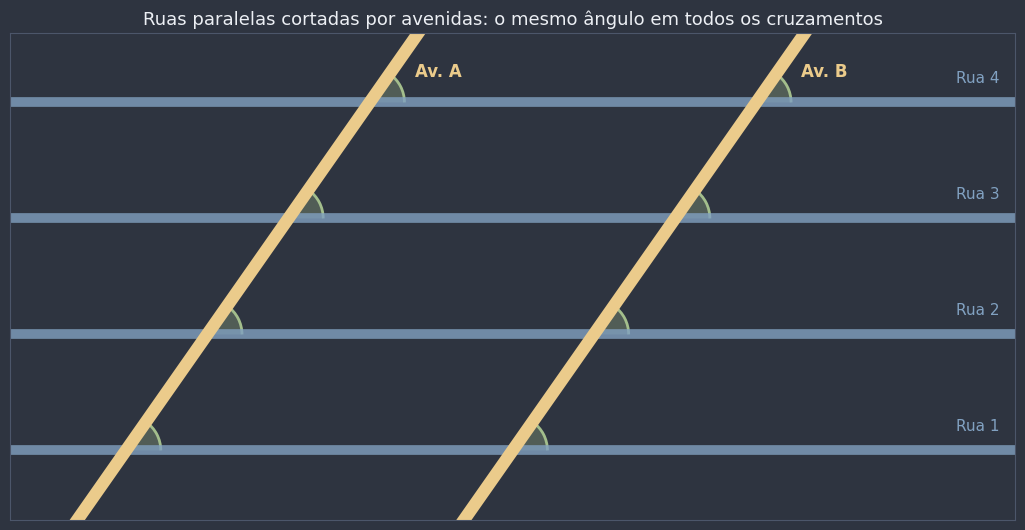

cruzamento,ângulo medido (tipo 1),o suplemento (tipo 2)
Av. A × Rua 1,55.0°,125.0°
Av. A × Rua 2,55.0°,125.0°
Av. A × Rua 3,55.0°,125.0°
Av. A × Rua 4,55.0°,125.0°
Av. B × Rua 1,55.0°,125.0°
Av. B × Rua 2,55.0°,125.0°
Av. B × Rua 3,55.0°,125.0°
Av. B × Rua 4,55.0°,125.0°


In [11]:
ruas = {f"Rua {k + 1}": np.array([0.0, 1.5 * k]) for k in range(4)}  # todas horizontais (inclinação 0°)
avenidas = {"Av. A": (np.array([1.0, 0.0]), 55), "Av. B": (np.array([6.0, 0.0]), 55)}

fig, ax = plt.subplots(figsize=(12, 5.4))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-0.5, -0.9), (12.5, 5.4)], margem=0)
for nome, ponto in ruas.items():
    ax.plot([-1, 13], [ponto[1], ponto[1]], color=COR_SECUNDARIA, lw=7, alpha=0.8, solid_capstyle="butt")
    ax.text(12.3, ponto[1] + 0.25, nome, color=COR_SECUNDARIA, fontsize=11, ha="right")
linhas = []
for nome_av, (ponto_av, inclinacao) in avenidas.items():
    desenhar_reta(ax, ponto_av, inclinacao, cor=COR_AVISO, largura=9)
    for nome_rua, ponto_rua in ruas.items():
        X = cruzamento(ponto_rua, 0, ponto_av, inclinacao)
        angulo = medir_angulo(X, X + direcao(0), X + direcao(inclinacao))
        desenhar_setor(ax, X, 0, angulo, raio=0.45, cor=COR_DESTAQUE)
        linhas.append({"cruzamento": f"{nome_av} × {nome_rua}", "ângulo medido (tipo 1)": f"{angulo:.1f}°",
                       "o suplemento (tipo 2)": f"{180 - angulo:.1f}°"})
    fim = ponto_av + 5.9 * direcao(inclinacao)
    ax.text(*(fim + np.array([0.35, 0])), nome_av, color=COR_AVISO, fontsize=12, fontweight="bold")
ax.set_title("Ruas paralelas cortadas por avenidas: o mesmo ângulo em todos os cruzamentos",
             color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()
display(pd.DataFrame(linhas).style.hide(axis="index"))

Oito cruzamentos, um só ângulo (e o seu suplemento). Um taxista que memoriza "a avenida corta as ruas a 55°" já sabe o formato de **todas** as esquinas dela.

📖 **Leitura complementar:** [Ângulo oposto pelo vértice](https://pt.wikipedia.org/wiki/%C3%82ngulo_oposto_pelo_v%C3%A9rtice)

**Pergunta de checagem:** duas retas paralelas são cortadas por uma transversal, e um dos ângulos formados mede 70°. Quanto mede o seu **alterno interno**? E o seu **colateral interno**? (Dica: primeiro decida se o ângulo de 70° é interno ou externo; se ele for externo, o que muda?)

**Pergunta de checagem:** uma transversal corta as retas $a$ e $b$ formando dois colaterais internos de 95° e 85°. As retas são paralelas? E se os dois medissem 95°?

## 3. Demonstração: a soma dos ângulos internos de um triângulo é 180°

Chegou a hora de pagar a dívida de [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb). Lá, o 180° foi **verificado** (medindo triângulos sorteados) e **ilustrado** (recortando cantos). Agora ele vai ser **demonstrado** para **todos** os triângulos de uma vez, usando só duas ferramentas deste notebook: o **postulado das paralelas** (seção 1) e os **ângulos alternos internos** (seção 2).

📌 **Teorema (soma dos ângulos internos):** em todo triângulo $ABC$, $\hat{A} + \hat{B} + \hat{C} = 180^\circ$.

- **Hipótese** (o que sabemos): $ABC$ é um triângulo.
- **Tese** (o que queremos provar): $\hat{A} + \hat{B} + \hat{C} = 180^\circ$.

**Construção auxiliar:** pelo vértice $C$, trace a reta $r$ **paralela** ao lado $\overline{AB}$ (ela existe e é única, pelo postulado das paralelas). Marque em $r$ um ponto $D$ do lado de $A$ e um ponto $E$ do lado de $B$ (na figura, $D$ à esquerda de $C$ e $E$ à direita). Agora olhe para $r$ e para a reta $\overleftrightarrow{AB}$ como **duas paralelas**, e para os lados $\overline{AC}$ e $\overline{BC}$ como **duas transversais**: são os "Z" da dica da seção 2.

**Demonstração:**

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $r \parallel \overleftrightarrow{AB}$, com $C \in r$ | construção (postulado das paralelas) |
| 2 | $D\hat{C}A \equiv C\hat{A}B$, ou seja, $D\hat{C}A = \hat{A}$ | alternos internos: $r \parallel \overleftrightarrow{AB}$ cortadas pela transversal $\overleftrightarrow{AC}$ |
| 3 | $E\hat{C}B \equiv A\hat{B}C$, ou seja, $E\hat{C}B = \hat{B}$ | alternos internos: $r \parallel \overleftrightarrow{AB}$ cortadas pela transversal $\overleftrightarrow{BC}$ |
| 4 | $D\hat{C}A + A\hat{C}B + B\hat{C}E = 180^\circ$ | os três ângulos, lado a lado, formam o ângulo raso $D\hat{C}E$ ($D$, $C$ e $E$ estão em $r$) |
| 5 | $\hat{A} + \hat{C} + \hat{B} = 180^\circ$ | substituindo os passos 2 e 3 no passo 4 (e $A\hat{C}B$ é o próprio $\hat{C}$) ∎ |

É **exatamente** o recorte de papel de 0404a (os três cantos lado a lado formando um ângulo raso), só que agora os "cantos" $\hat{A}$ e $\hat{B}$ foram transportados até $C$ pelos ângulos **alternos internos**, sem tesoura e sem erro. E, como nenhum passo dependeu das medidas de um triângulo específico, o resultado vale para **qualquer** triângulo.

O computador não substitui a demonstração, mas ajuda a **ver** cada passo. A função abaixo refaz a construção para um triângulo dado: traça a paralela a $\overline{AB}$ por $C$ (a reta por $C$ com a **mesma inclinação** de $\overline{AB}$) e mede os três ângulos com vértice em $C$ ao longo dela.

In [12]:
def angulos_da_prova(A, B, C, desvio: float = 0.0) -> dict[str, float]:
    """Refaz a construção da demonstração para o triângulo ABC (com C 'acima' de AB, no sentido
    anti-horário A → B → C) e mede os ângulos envolvidos.

    A reta auxiliar passa por C com a inclinação de AB mais `desvio` graus (desvio 0 = a paralela).
    Os ângulos em C são medidos no sentido anti-horário: de D até A, de A até B e de B até E.
    """
    A, B, C = (np.array(p, dtype=float) for p in (A, B, C))
    inclinacao = direcao_de(A, B) + desvio
    D, E = C - 1.8 * direcao(inclinacao), C + 1.8 * direcao(inclinacao)
    dir_D, dir_A, dir_B, dir_E = (direcao_de(C, P) for P in (D, A, B, E))
    return {
        "Â": medir_angulo(A, B, C), "B̂": medir_angulo(B, C, A), "Ĉ": medir_angulo(C, A, B),
        "DĈA": (dir_A - dir_D) % 360, "AĈB": (dir_B - dir_A) % 360, "BĈE": (dir_E - dir_B) % 360,
        "D": D, "E": E,
    }


triangulos = {
    "acutângulo": ((0, 0), (6, 0), (2.5, 3.5)),
    "retângulo em A": ((0, 0), (6, 0), (0, 4)),
    "obtusângulo em A": ((0, 0), (6, 0), (-2.5, 2.5)),
    "obtusângulo em B": ((0, 0), (6, 0), (8.5, 1.5)),
    "quase achatado": ((0, 0), (6, 0), (3.2, 0.15)),
    "girado e deslocado": ((1, -2), (5, 1), (-1, 3)),
}
linhas = []
for nome, (A, B, C) in triangulos.items():
    m = angulos_da_prova(A, B, C)
    linhas.append({
        "triângulo": nome, "Â": m["Â"], "DĈA": m["DĈA"], "B̂": m["B̂"], "BĈE": m["BĈE"], "Ĉ": m["Ĉ"],
        "DĈA + AĈB + BĈE": m["DĈA"] + m["AĈB"] + m["BĈE"],
        "passos 2 e 3 conferem?": "✅" if math.isclose(m["DĈA"], m["Â"]) and math.isclose(m["BĈE"], m["B̂"]) else "❌",
        "Â + B̂ + Ĉ": m["Â"] + m["B̂"] + m["Ĉ"],
    })
formato = {coluna: "{:.2f}°" for coluna in ["Â", "DĈA", "B̂", "BĈE", "Ĉ", "DĈA + AĈB + BĈE", "Â + B̂ + Ĉ"]}
display(pd.DataFrame(linhas).style.format(formato).hide(axis="index"))

triângulo,Â,DĈA,B̂,BĈE,Ĉ,DĈA + AĈB + BĈE,passos 2 e 3 conferem?,Â + B̂ + Ĉ
acutângulo,54.46°,54.46°,45.00°,45.00°,80.54°,180.00°,✅,180.00°
retângulo em A,90.00°,90.00°,33.69°,33.69°,56.31°,180.00°,✅,180.00°
obtusângulo em A,135.00°,135.00°,16.39°,16.39°,28.61°,180.00°,✅,180.00°
obtusângulo em B,10.01°,10.01°,149.04°,149.04°,20.96°,180.00°,✅,180.00°
quase achatado,2.68°,2.68°,3.07°,3.07°,174.25°,180.00°,✅,180.00°
girado e deslocado,74.93°,74.93°,55.30°,55.30°,49.76°,180.00°,✅,180.00°


Em todos os triângulos, inclusive nos obtusângulos, no retângulo, no quase achatado e no girado (em que $\overline{AB}$ nem é horizontal), $D\hat{C}A$ bate com $\hat{A}$, $B\hat{C}E$ bate com $\hat{B}$, e a soma dá 180°. Agora a representação gráfica: à esquerda, o que queremos provar; à direita, a construção auxiliar, com cada ângulo transportado pintado da **mesma cor** do original.

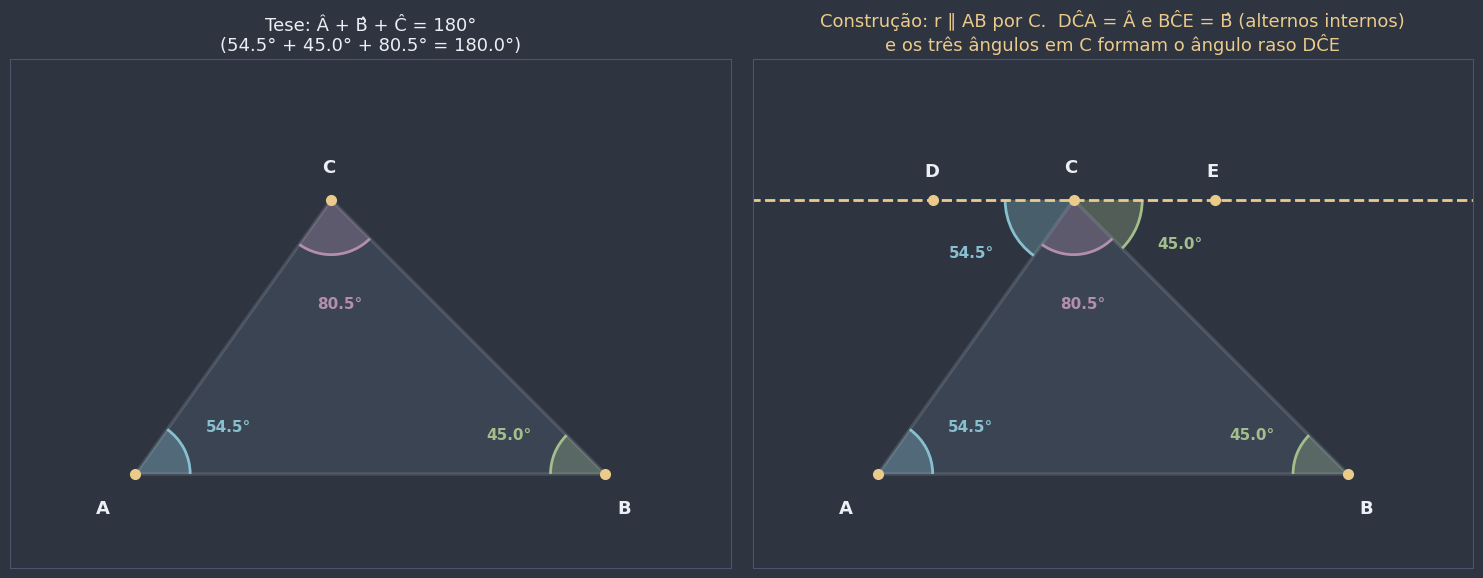

In [13]:
def desenhar_demonstracao(ax, A, B, C, desvio: float = 0.0, mostrar_paralela: bool = True,
                          raio: float = 0.7) -> dict[str, float]:
    """Desenha o triângulo ABC com os ângulos internos e, se pedido, a reta auxiliar por C
    com os ângulos DĈA e BĈE. Devolve as medidas de `angulos_da_prova`."""
    A, B, C = (np.array(p, dtype=float) for p in (A, B, C))
    m = angulos_da_prova(A, B, C, desvio)
    ax.add_patch(Polygon([A, B, C], closed=True, facecolor=COR_SECUNDARIA, alpha=0.15, edgecolor=NORD_TEXTO_SEC,
                         lw=2.5))
    desenhar_arco(ax, A, B, C, raio=raio, cor=COR_PONTO, rotulo=f"{m['Â']:.1f}°", raio_rotulo=1.9 * raio)
    desenhar_arco(ax, B, C, A, raio=raio, cor=COR_DESTAQUE, rotulo=f"{m['B̂']:.1f}°", raio_rotulo=1.9 * raio)
    desenhar_setor(ax, C, direcao_de(C, A), m["AĈB"], raio=raio, cor=COR_EXTRA, rotulo=f"{m['Ĉ']:.1f}°",
                   raio_rotulo=1.9 * raio)
    if mostrar_paralela:
        cor_reta = COR_AVISO if desvio == 0 else COR_ALERTA
        desenhar_reta(ax, C, direcao_de(A, B) + desvio, cor=cor_reta, estilo="--", largura=2)
        if 0 < m["DĈA"] < 180 and 0 < m["BĈE"] < 180:
            desenhar_setor(ax, C, direcao_de(C, m["D"]), m["DĈA"], raio=1.25 * raio, cor=COR_PONTO,
                           rotulo=f"{m['DĈA']:.1f}°", raio_rotulo=2.1 * raio)
            desenhar_setor(ax, C, direcao_de(C, B), m["BĈE"], raio=1.25 * raio, cor=COR_DESTAQUE,
                           rotulo=f"{m['BĈE']:.1f}°", raio_rotulo=2.1 * raio)
        for P, nome in ((m["D"], "D"), (m["E"], "E")):
            desenhar_ponto(ax, P, nome, cor=cor_reta, deslocamento=(-0.1, 0.3))
    for P, nome, d in [(A, "A", (-0.5, -0.5)), (B, "B", (0.15, -0.5)), (C, "C", (-0.12, 0.35))]:
        desenhar_ponto(ax, P, nome, deslocamento=d)
    return m


A, B, C = (0, 0), (6, 0), (2.5, 3.5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.6))
fig.patch.set_facecolor(NORD_FUNDO)
for ax in (ax1, ax2):
    preparar_eixo(ax, [(-1.5, -1.1), (7.5, 5.2)], margem=0.1)
m = desenhar_demonstracao(ax1, A, B, C, mostrar_paralela=False)
ax1.set_title(f"Tese: Â + B̂ + Ĉ = 180°\n({m['Â']:.1f}° + {m['B̂']:.1f}° + {m['Ĉ']:.1f}° = "
              f"{m['Â'] + m['B̂'] + m['Ĉ']:.1f}°)", color=NORD_TEXTO, fontsize=13)
desenhar_demonstracao(ax2, A, B, C)
ax2.set_title("Construção: r ∥ AB por C.  DĈA = Â e BĈE = B̂ (alternos internos)\n"
              "e os três ângulos em C formam o ângulo raso DĈE", color=COR_AVISO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** $A$ e $B$ estão fixos; os sliders `x de C` e `y de C` movem o terceiro vértice. A reta tracejada é redesenhada sempre **paralela** a $\overline{AB}$ passando por $C$, e as cópias de $\hat{A}$ e $\hat{B}$ aparecem em $C$. Estique, achate, deixe o triângulo obtusângulo: a soma no título nunca sai de 180°.

Depois, experimente o slider `desvio`: ele **gira** a reta auxiliar em torno de $C$, de modo que ela **deixa de ser paralela** a $\overline{AB}$. Os três ângulos em $C$ continuam somando 180° (eles ainda formam um ângulo raso), mas os ângulos das pontas **não são mais** cópias de $\hat{A}$ e $\hat{B}$, e a demonstração desmorona. É a resposta visual para a pergunta "por que a reta precisa ser paralela?".

In [ ]:
def explorar_demonstracao(x_C: float, y_C: float, desvio: int) -> None:
    A, B, C = (0.0, 0.0), (6.0, 0.0), (x_C, y_C)
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-5, -1.3), (11.2, 7.3)], margem=0)
    m = desenhar_demonstracao(ax, A, B, C, desvio=desvio, raio=0.6)
    soma = m["Â"] + m["B̂"] + m["Ĉ"]
    if desvio == 0:
        titulo = (f"Â + B̂ + Ĉ = {m['Â']:.1f}° + {m['B̂']:.1f}° + {m['Ĉ']:.1f}° = {soma:.1f}°   "
                  f"(DĈA = Â e BĈE = B̂ ✓)")
        cor = COR_DESTAQUE
    elif not (0 < m["DĈA"] < 180 and 0 < m["BĈE"] < 180):
        titulo, cor = "a reta auxiliar entrou no triângulo: diminua o desvio", COR_ALERTA
    else:
        titulo = (f"reta NÃO paralela: DĈA = {m['DĈA']:.1f}° ≠ Â = {m['Â']:.1f}°  e  "
                  f"BĈE = {m['BĈE']:.1f}° ≠ B̂ = {m['B̂']:.1f}°  ✗")
        cor = COR_ALERTA
    ax.set_title(titulo, color=cor, fontsize=12)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_demonstracao,
    x_C=widgets.FloatSlider(value=2.5, min=-3, max=9, step=0.25, description="x de C:"),
    y_C=widgets.FloatSlider(value=3.5, min=0.75, max=6, step=0.25, description="y de C:"),
    desvio=widgets.IntSlider(value=0, min=-30, max=30, step=5, description="desvio (°):"),
);

interactive(children=(FloatSlider(value=2.5, description='x de C:', max=9.0, min=-3.0, step=0.25), FloatSlider…

📎 **Conexão:** este é o fio que ficou pendente desde [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb). Lá, o 180° foi usado para tirar várias consequências: no máximo um ângulo reto ou obtuso por triângulo, 60° em cada ângulo do equilátero, agudos complementares no triângulo retângulo e o teorema do ângulo externo. Todas eram tão confiáveis quanto o 180° em que se apoiavam, e agora o 180° está **demonstrado**. De quebra, a mesma paralela auxiliar demonstra **diretamente** o teorema do ângulo externo: é o Exercício Desafio 6.

💡 **Dica — a técnica da paralela auxiliar:** a demonstração só funcionou porque **acrescentamos** à figura uma reta que não estava lá. Traçar uma paralela auxiliar (como traçamos a bissetriz na demonstração do isósceles em [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb)) é uma das técnicas mais usadas em geometria, e vai voltar mais à frente, por exemplo na **base média** de triângulos e trapézios, em [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb).

🕵️ **Curiosidade histórica:** segundo Proclo, comentador de Euclides do século V, o historiador Eudemo atribuía aos **pitagóricos** a descoberta de que os ângulos internos de um triângulo somam "dois retos", com uma prova que traçava, por um vértice, a paralela ao lado oposto (a mesma da nossa tabela). Nos *Elementos*, o resultado é a Proposição 32 do Livro I, que prova de uma só vez o teorema do ângulo externo e a soma 180°, com uma paralela auxiliar e o prolongamento de um lado.

**Pergunta de checagem:** por que a escolha de uma reta **paralela** ao lado oposto (e não de uma reta qualquer passando por $C$) é essencial para a demonstração? Em qual passo da tabela isso é usado?

**Pergunta de checagem:** numa superfície esférica, não existem paralelas. Qual passo da demonstração não poderia ser feito ali? Isso é coerente com o triângulo de 270° de 0404a?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Retas paralelas | $r \parallel s$: coplanares e **sem ponto em comum**, ou **coincidentes** (convenção do curso: toda reta é paralela a si mesma) |
| Posições relativas no plano | **concorrentes** (1 ponto em comum), **paralelas distintas** (nenhum), **coincidentes** (todos) |
| Retas reversas | no espaço, retas que não se cruzam **sem** ser paralelas (não são coplanares) |
| Postulado das paralelas | por um ponto fora de $r$ passa **uma única** paralela a $r$ (aceito sem prova; equivalente ao 5º postulado de Euclides) |
| Geometrias não euclidianas | trocando o postulado: hiperbólica (infinitas paralelas, soma < 180°) e esférica (nenhuma paralela, soma > 180°) |
| Transversal | reta que corta duas outras em pontos distintos, formando **8 ângulos** (1 a 4 em $r$, 5 a 8 em $s$) |
| Correspondentes (**F**) | 1–5, 2–6, 3–7, 4–8: **congruentes** se $r \parallel s$ |
| Alternos internos (**Z**) | 3–5, 4–6: **congruentes** se $r \parallel s$ |
| Alternos externos | 1–7, 2–8: **congruentes** se $r \parallel s$ |
| Colaterais internos (**U**) | 3–6, 4–5: **suplementares** se $r \parallel s$ |
| Colaterais externos | 1–8, 2–7: **suplementares** se $r \parallel s$ |
| Com $r \parallel s$ | só **duas** medidas: $\alpha$ (ângulos 1, 3, 5, 7) e $180^\circ - \alpha$ (ângulos 2, 4, 6, 8) |
| ⚠️ Cuidado | as relações acima **só valem se $r \parallel s$**; o.p.v. congruentes e adjacentes suplementares valem sempre |
| Recíproca | correspondentes ou alternos congruentes, ou colaterais suplementares $\Rightarrow r \parallel s$ |
| Soma dos ângulos do triângulo | paralela a $\overline{AB}$ por $C$ + dois pares de **alternos internos** + ângulo raso: $\hat{A} + \hat{B} + \hat{C} = 180^\circ$ |

**A ideia central:** retas paralelas "transportam" ângulos. Uma transversal que corta duas paralelas repete o mesmo ângulo nos dois cruzamentos, e é esse transporte que leva $\hat{A}$ e $\hat{B}$ até o vértice $C$ e prova o 180°. Tudo isso se apoia num único postulado, que não se demonstra, e sem o qual a geometria seria outra.

## Exercícios

**Básico**
1. Calcular os oito ângulos formados por uma transversal com duas paralelas, a partir de um deles.
2. Classificar pares de ângulos (correspondentes, alternos, colaterais, opostos pelo vértice) e dizer se são congruentes ou suplementares.

**Intermediário**

3. Escrever uma função que decide, a partir de um par de ângulos, se as retas cortadas são paralelas (a "volta" da propriedade).
4. Reproduzir em código a demonstração da seção 3 e conferir com `assert` que a soma dá 180° em triângulos variados.

**Desafio**

5. Encontrar um ângulo numa figura com duas paralelas e duas transversais, encadeando as relações entre os ângulos.
6. Demonstrar, com a mesma paralela auxiliar da seção 3, o teorema do ângulo externo.

Gabarito completo com resolução comentada em [`0406b_paralelismo_gabarito.ipynb`](0406b_paralelismo_gabarito.ipynb) — tente resolver sozinho antes de olhar.

In [15]:
# Ferramenta usada pelas células de verificação: execute esta célula antes dos exercícios.
import unicodedata


def normalizar(texto) -> str:
    """Tira acentos, pontos, espaços extras e maiúsculas, para aceitar 'Alternos Internos'
    tanto quanto 'alternos internos' (e 'o.p.v.' tanto quanto 'opv')."""
    sem_acento = unicodedata.normalize("NFD", str(texto)).encode("ascii", "ignore").decode()
    return " ".join(sem_acento.replace(".", "").lower().split())

### Básico

Execute a célula abaixo para ver a figura dos Exercícios Básicos 1 e 2.

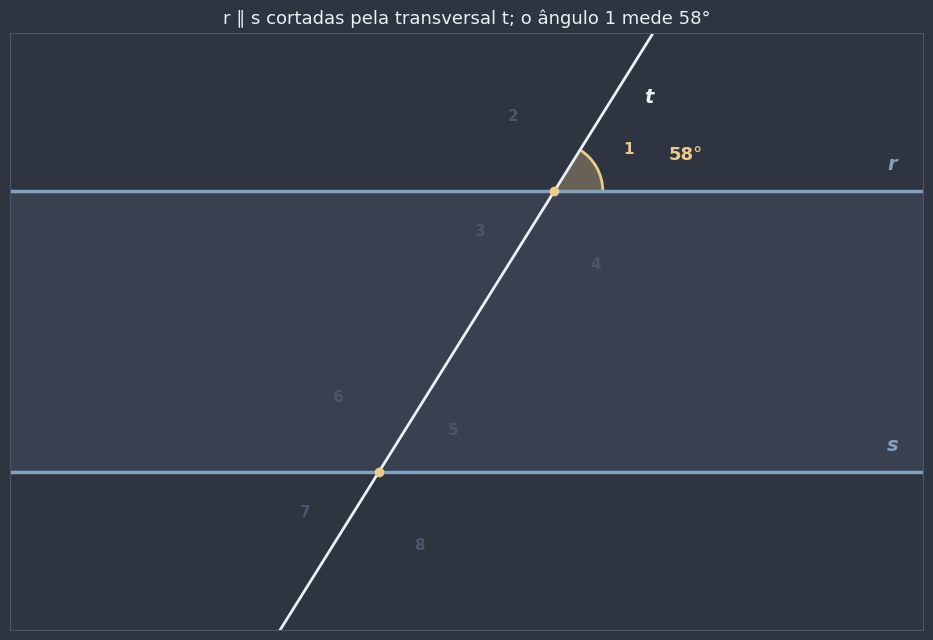

In [16]:
# Figura dos Exercícios Básicos 1 e 2 (apenas desenha; não precisa alterar)
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor(NORD_FUNDO)
desenhar_transversal(ax, 58, destaque={1: COR_AVISO}, raio=0.55)
ax.text(*(cruzamentos(58)[0] + np.array([1.3, 0.35])), "58°", color=COR_AVISO, fontsize=13, fontweight="bold")
ax.set_title("r ∥ s cortadas pela transversal t; o ângulo 1 mede 58°", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Básico 1: na figura, r ∥ s e o ângulo 1 mede 58°.
# Complete o dicionário com a medida, em graus, de cada um dos oito ângulos.
# Use as relações da seção 2 (e não o transferidor!).
angulos_ex1 = {1: 58, 2: ..., 3: ..., 4: ..., 5: ..., 6: ..., 7: ..., 8: ...}

print(angulos_ex1)

In [ ]:
# Verificação
certos_ex1 = {1: 58, 2: 122, 3: 58, 4: 122, 5: 58, 6: 122, 7: 58, 8: 122}
dicas_ex1 = {
    1: "o ângulo 1 é dado no enunciado",
    2: "2 e 1 são adjacentes e, juntos, formam um ângulo raso",
    3: "3 é oposto pelo vértice ao 1",
    4: "4 é oposto pelo vértice ao 2",
    5: "5 é correspondente ao 1",
    6: "6 é correspondente ao 2 (ou alterno interno do 4)",
    7: "7 é correspondente ao 3 (ou alterno externo do 1)",
    8: "8 é correspondente ao 4 (ou colateral externo do 1)",
}
for numero, certo in certos_ex1.items():
    resposta = angulos_ex1.get(numero, ...)
    assert resposta is not ... and math.isclose(resposta, certo), (
        f"Tente de novo, revise o ângulo {numero}: {dicas_ex1[numero]} (seção 2 - Ângulos formados por duas retas e uma transversal)."
    )
print("Certo!")

In [ ]:
# Exercício Básico 2: ainda na figura (r ∥ s), classifique cada par de ângulos como
# "correspondentes", "alternos internos", "alternos externos", "colaterais internos",
# "colaterais externos" ou "opostos pelo vértice":
#   (a) 1 e 5    (b) 3 e 5    (c) 2 e 8    (d) 4 e 5    (e) 2 e 7    (f) 6 e 8
# Depois, para cada par, diga se os dois ângulos são "congruentes" ou "suplementares".
# Responda com duas listas de textos, na ordem (a) a (f).
classificacao_ex2 = [..., ..., ..., ..., ..., ...]
relacao_ex2 = [..., ..., ..., ..., ..., ...]

print(classificacao_ex2)
print(relacao_ex2)

In [ ]:
# Verificação
gabarito_ex2 = ["correspondentes", "alternos internos", "alternos externos", "colaterais internos",
                "colaterais externos", "opostos pelo vertice"]
relacoes_ex2 = ["congruentes", "congruentes", "congruentes", "suplementares", "suplementares", "congruentes"]
assert classificacao_ex2 is not ... and len(classificacao_ex2) == 6, (
    "Tente de novo, revise: a lista precisa ter uma classificação para cada um dos 6 pares (seção 2 - Ângulos formados por duas retas e uma transversal)."
)
for item, resposta, certa in zip("abcdef", classificacao_ex2, gabarito_ex2):
    aceitas = {certa, "opv"} if certa == "opostos pelo vertice" else {certa}
    assert resposta is not ... and normalizar(resposta) in aceitas, (
        f"Tente de novo, revise o item ({item}): veja se os ângulos estão no mesmo cruzamento, se são internos "
        f"ou externos e se estão do mesmo lado da transversal (seção 2 - Ângulos formados por duas retas e uma transversal)."
    )
assert relacao_ex2 is not ... and len(relacao_ex2) == 6, (
    "Tente de novo, revise: a lista de relações precisa ter 6 respostas (seção 2 - Ângulos formados por duas retas e uma transversal)."
)
for item, resposta, certa in zip("abcdef", relacao_ex2, relacoes_ex2):
    assert resposta is not ... and normalizar(resposta) == certa, (
        f"Tente de novo, revise a relação do item ({item}): correspondentes, alternos e o.p.v. são congruentes; "
        f"colaterais são suplementares (seção 2 - Ângulos formados por duas retas e uma transversal)."
    )
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: a "volta" da propriedade.
# Complete a função `sao_paralelas_ex3`, que recebe o tipo de um par de ângulos formados por uma
# transversal com duas retas r e s ("correspondentes", "alternos internos", "alternos externos",
# "colaterais internos" ou "colaterais externos") e as medidas dos dois ângulos do par, e devolve
# True se essas medidas garantem que r ∥ s, e False caso contrário.
# Dica: para quais tipos a condição é "congruentes"? E para quais é "suplementares"?
# Compare medidas com math.isclose, nunca com ==.


def sao_paralelas_ex3(tipo: str, medida_1: float, medida_2: float) -> bool:
    ...


print(sao_paralelas_ex3("alternos internos", 72, 72))
print(sao_paralelas_ex3("colaterais internos", 60, 60))

In [ ]:
# Verificação
casos_ex3 = [
    ("alternos internos", 72, 72, True),
    ("alternos internos", 72, 108, False),
    ("colaterais internos", 110, 70, True),
    ("colaterais internos", 60, 60, False),
    ("correspondentes", 85, 95, False),
    ("correspondentes", 40.5, 40.5, True),
    ("alternos externos", 130, 130, True),
    ("colaterais externos", 100, 80, True),
    ("colaterais externos", 90, 90, True),
    ("colaterais externos", 100, 100, False),
]
for tipo, m1, m2, certo in casos_ex3:
    resposta = sao_paralelas_ex3(tipo, m1, m2)
    assert resposta is certo, (
        f"Tente de novo, revise: para {tipo} medindo {m1}° e {m2}°, a função deveria devolver {certo}; "
        f"correspondentes e alternos precisam ser congruentes, colaterais precisam somar 180° "
        f"(recíproca da seção 2 - Ângulos formados por duas retas e uma transversal)."
    )
print("Certo!")

In [ ]:
# Exercício Intermediário 4: a demonstração da seção 3, em código.
# Complete a função `angulos_em_C_ex4`, que recebe os vértices A, B e C de um triângulo (como
# np.array) e:
#   1. constrói os pontos D = C − (B − A) e E = C + (B − A), que estão na reta paralela a AB
#      passando por C (a partir de C, andamos na mesma direção de AB, para os dois lados);
#   2. mede, com `medir_angulo`, os três ângulos com vértice em C ao longo dessa reta:
#      DĈA, AĈB e BĈE;
#   3. devolve os três, nessa ordem, numa tupla.
# A verificação testa a função em vários triângulos (acutângulos, retângulos e obtusângulos),
# conferindo que DĈA = Â, que BĈE = B̂ e que a soma dá 180°.


def angulos_em_C_ex4(A, B, C) -> tuple[float, float, float]:
    ...


print(angulos_em_C_ex4(np.array([0, 0]), np.array([6, 0]), np.array([2, 4])))

In [ ]:
# Verificação
triangulos_ex4 = [
    ((0, 0), (6, 0), (2, 4), "acutângulo"),
    ((0, 0), (6, 0), (0, 5), "retângulo em A"),
    ((0, 0), (6, 0), (-3, 2), "obtusângulo em A"),
    ((0, 0), (6, 0), (9, 1), "obtusângulo em B"),
    ((1, -2), (4, 5), (-3, 1), "girado e deslocado"),
    ((0, 0), (6, 0), (3, 0.2), "quase achatado"),
]
for *vertices, descricao in triangulos_ex4:
    A, B, C = (np.array(p, dtype=float) for p in vertices)
    resposta = angulos_em_C_ex4(A, B, C)
    assert resposta is not None and resposta is not ... and len(resposta) == 3, (
        "Tente de novo, revise: a função precisa devolver uma tupla com as três medidas (DĈA, AĈB, BĈE) "
        "(seção 3 - A soma dos ângulos internos do triângulo)."
    )
    dca, acb, bce = resposta
    assert math.isclose(dca, medir_angulo(A, B, C)), (
        f"Tente de novo, revise: no triângulo {descricao}, DĈA deveria ser igual a Â (alternos internos, "
        f"transversal AC); confira D = C − (B − A) e a ordem medir_angulo(C, D, A) (seção 3 - A soma dos ângulos internos do triângulo)."
    )
    assert math.isclose(bce, medir_angulo(B, C, A)), (
        f"Tente de novo, revise: no triângulo {descricao}, BĈE deveria ser igual a B̂ (alternos internos, "
        f"transversal BC); confira E = C + (B − A) e a ordem medir_angulo(C, B, E) (seção 3 - A soma dos ângulos internos do triângulo)."
    )
    assert math.isclose(acb, medir_angulo(C, A, B)), (
        f"Tente de novo, revise: AĈB é o próprio ângulo interno Ĉ: medir_angulo(C, A, B) (seção 3 - A soma dos ângulos internos do triângulo)."
    )
    assert math.isclose(dca + acb + bce, 180), (
        f"Tente de novo, revise: os três ângulos em C formam um ângulo raso (seção 3 - A soma dos ângulos internos do triângulo)."
    )
print("Certo!")

### Desafio

Execute a célula abaixo para ver a figura do Exercício Desafio 5.

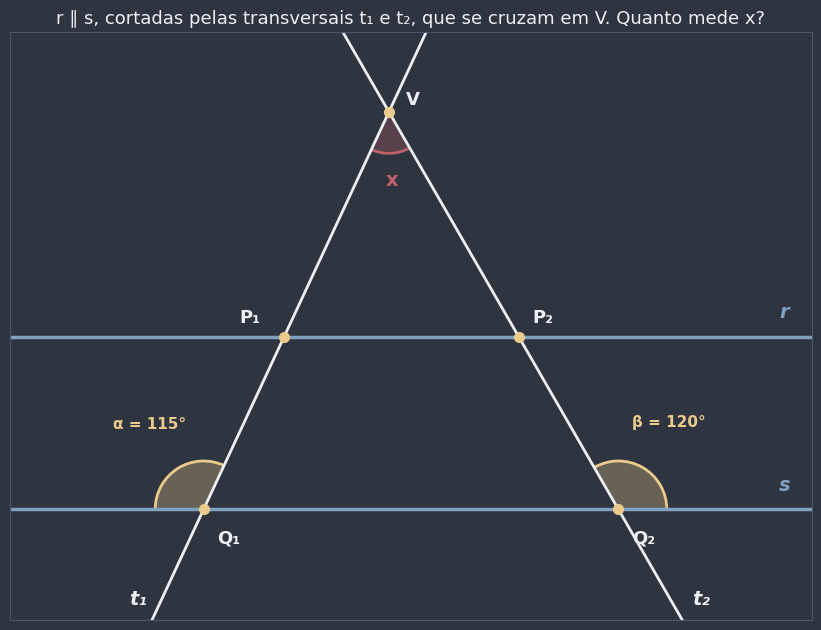

In [17]:
# Figura do Exercício Desafio 5 (apenas desenha; não precisa alterar)
Q1_5, Q2_5 = np.array([2.0, 0.0]), np.array([8.0, 0.0])  # t1 e t2 cortam s nesses pontos
P1_5 = cruzamento(Q1_5, 65, (0, 2.5), 0)                 # t1 corta r
P2_5 = cruzamento(Q2_5, 120, (0, 2.5), 0)                # t2 corta r
V_5 = cruzamento(Q1_5, 65, Q2_5, 120)                    # t1 e t2 se cruzam em V

fig, ax = plt.subplots(figsize=(10, 6.4))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-0.8, -1.6), (10.8, 6.9)], margem=0)
desenhar_reta(ax, (0, 2.5), 0, cor=COR_SECUNDARIA, nome="r", posicao_nome=(10.4, 2.85))
desenhar_reta(ax, (0, 0), 0, cor=COR_SECUNDARIA, nome="s", posicao_nome=(10.4, 0.35))
desenhar_reta(ax, Q1_5, 65, cor=NORD_TEXTO, largura=2, nome="t₁", posicao_nome=(1.05, -1.3))
desenhar_reta(ax, Q2_5, 120, cor=NORD_TEXTO, largura=2, nome="t₂", posicao_nome=(9.2, -1.3))
desenhar_setor(ax, Q1_5, 65, 115, raio=0.7, cor=COR_AVISO, rotulo="α = 115°", raio_rotulo=1.45)
desenhar_setor(ax, Q2_5, 0, 120, raio=0.7, cor=COR_AVISO, rotulo="β = 120°", raio_rotulo=1.45)
desenhar_arco(ax, V_5, P1_5, P2_5, raio=0.6, cor=COR_ALERTA, rotulo="x", raio_rotulo=1.0, tamanho_fonte=14)
for P, nome, d in [(Q1_5, "Q₁", (0.2, -0.5)), (Q2_5, "Q₂", (0.2, -0.5)), (P1_5, "P₁", (-0.65, 0.2)),
                   (P2_5, "P₂", (0.2, 0.2)), (V_5, "V", (0.25, 0.1))]:
    desenhar_ponto(ax, P, nome, deslocamento=d)
ax.set_title("r ∥ s, cortadas pelas transversais t₁ e t₂, que se cruzam em V. Quanto mede x?",
             color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Desafio 5: encadeando as relações.
# Na figura, r ∥ s. A transversal t₁ corta s em Q₁ e r em P₁; a transversal t₂ corta s em Q₂ e
# r em P₂; t₁ e t₂ se cruzam em V, acima de r. São dados:
#   α = 115°: o ângulo em Q₁ entre s (para a esquerda) e t₁ (para cima);
#   β = 120°: o ângulo em Q₂ entre s (para a direita) e t₂ (para cima).
# Queremos x, o ângulo P₁V̂P₂. Siga os passos (todas as respostas em graus):
# (a) Em P₁, o ângulo entre r (para a esquerda) e t₁ (para cima) é o correspondente de α.
#     Quanto ele mede? Guarde em `angulo_a_ex5`.
# (b) Quanto mede o ângulo interno do triângulo VP₁P₂ em P₁, ou seja, VP̂₁P₂ (entre r, para a
#     direita, e t₁, para cima)? Guarde em `angulo_VP1P2_ex5`.
# (c) Em P₂, o ângulo entre r (para a direita) e t₂ (para baixo) forma com β um par de ângulos.
#     Que par é esse? Guarde o nome em `relacao_c_ex5`. Use-o para achar o ângulo VP̂₂P₁
#     (entre r, para a esquerda, e t₂, para cima), que é oposto pelo vértice a ele.
#     Guarde em `angulo_VP2P1_ex5`.
# (d) Quanto mede x? Guarde em `x_ex5`.
angulo_a_ex5 = ...
angulo_VP1P2_ex5 = ...
relacao_c_ex5 = ...
angulo_VP2P1_ex5 = ...
x_ex5 = ...

print(angulo_a_ex5, angulo_VP1P2_ex5, relacao_c_ex5, angulo_VP2P1_ex5, x_ex5)

In [ ]:
# Verificação
assert angulo_a_ex5 is not ... and math.isclose(angulo_a_ex5, 115), (
    "Tente de novo, revise: ângulos correspondentes entre paralelas são congruentes (seção 2 - Ângulos formados por duas retas e uma transversal)."
)
assert angulo_VP1P2_ex5 is not ... and math.isclose(angulo_VP1P2_ex5, 65), (
    "Tente de novo, revise: em P₁, o ângulo do item (a) e VP̂₁P₂ são adjacentes e formam um ângulo raso "
    "(seção 2 - Ângulos formados por duas retas e uma transversal)."
)
assert relacao_c_ex5 is not ... and normalizar(relacao_c_ex5) == "colaterais internos", (
    "Tente de novo, revise: os dois ângulos estão entre r e s (internos) e do mesmo lado de t₂ (seção 2 - Ângulos formados por duas retas e uma transversal)."
)
assert angulo_VP2P1_ex5 is not ... and math.isclose(angulo_VP2P1_ex5, 60), (
    "Tente de novo, revise: colaterais internos entre paralelas são suplementares, e o.p.v. são congruentes "
    "(seção 2 - Ângulos formados por duas retas e uma transversal)."
)
assert x_ex5 is not ... and math.isclose(x_ex5, 55), (
    "Tente de novo, revise: x é o terceiro ângulo do triângulo VP₁P₂, e a soma dos três é 180° (seção 3 - A soma dos ângulos internos do triângulo)."
)
print("Certo!")

Execute a célula abaixo para ver a figura do Exercício Desafio 6.

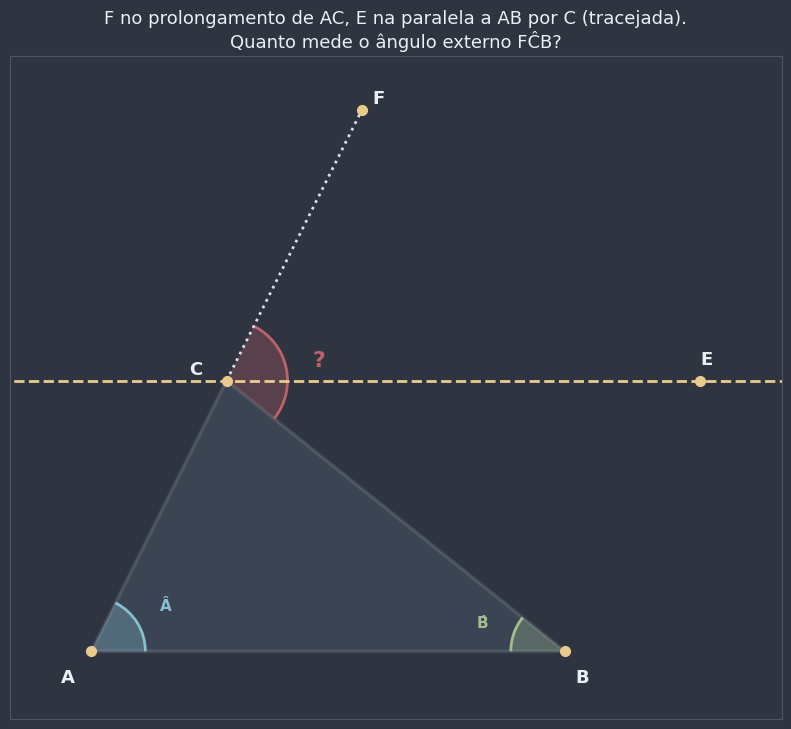

In [18]:
# Figura do Exercício Desafio 6 (apenas desenha; não precisa alterar)
A6, B6, C6 = np.array([0.0, 0.0]), np.array([7.0, 0.0]), np.array([2.0, 4.0])
E6_figura, F6_figura = C6 + (B6 - A6), C6 + (C6 - A6)

fig, ax = plt.subplots(figsize=(10, 7.4))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-1.2, -1.0), (10.2, 8.8)], margem=0)
ax.add_patch(Polygon([A6, B6, C6], closed=True, facecolor=COR_SECUNDARIA, alpha=0.15, edgecolor=NORD_TEXTO_SEC,
                     lw=2.5))
ax.plot(*zip(C6, F6_figura), color=NORD_TEXTO_SEC, lw=2, linestyle=":")
desenhar_reta(ax, C6, 0, cor=COR_AVISO, estilo="--", largura=2)
desenhar_arco(ax, A6, B6, C6, raio=0.8, cor=COR_PONTO, rotulo="Â", raio_rotulo=1.3)
desenhar_arco(ax, B6, C6, A6, raio=0.8, cor=COR_DESTAQUE, rotulo="B̂", raio_rotulo=1.3)
desenhar_arco(ax, C6, F6_figura, B6, raio=0.9, cor=COR_ALERTA, rotulo="?", raio_rotulo=1.4, tamanho_fonte=16)
for P, nome, d in [(A6, "A", (-0.45, -0.45)), (B6, "B", (0.15, -0.45)), (C6, "C", (-0.55, 0.1)),
                   (E6_figura, "E", (0.0, 0.25)), (F6_figura, "F", (0.15, 0.1))]:
    desenhar_ponto(ax, P, nome, deslocamento=d)
ax.set_title("F no prolongamento de AC, E na paralela a AB por C (tracejada).\nQuanto mede o ângulo externo FĈB?",
             color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Desafio 6: o teorema do ângulo externo, demonstrado.
# Em 0404a você viu, usando a soma 180°, que o ângulo externo em C é igual a Â + B̂.
# Agora vamos demonstrá-lo DIRETAMENTE, com a mesma ideia da seção 3: uma paralela a AB por C.
# Use o triângulo da figura: A = (0, 0), B = (7, 0), C = (2, 4).
# (a) Construa os pontos E = C + (B − A), na paralela a AB por C, e F = C + (C − A), no
#     prolongamento do lado AC além de C. Guarde em `E_ex6` e `F_ex6` (como np.array).
# (b) Use `medir_angulo` para medir FĈE e EĈB. Guarde em `angulo_FCE_ex6` e `angulo_ECB_ex6`.
# (c) Que relação da seção 2 garante que FĈE = Â? E que EĈB = B̂? Guarde os nomes
#     ("correspondentes", "alternos internos", ...) em `relacao_FCE_ex6` e `relacao_ECB_ex6`.
#     Dica: em FĈE, as paralelas AB e CE são cortadas pela transversal AF (a reta do lado AC);
#     em EĈB, a transversal é a reta BC.
# (d) Meça o ângulo externo FĈB e guarde em `externo_ex6`. Em `confere_ex6`, guarde o resultado
#     (True ou False) da comparação entre ele e Â + B̂, feita com math.isclose.
A6, B6, C6 = np.array([0.0, 0.0]), np.array([7.0, 0.0]), np.array([2.0, 4.0])

E_ex6 = ...
F_ex6 = ...
angulo_FCE_ex6 = ...
angulo_ECB_ex6 = ...
relacao_FCE_ex6 = ...
relacao_ECB_ex6 = ...
externo_ex6 = ...
confere_ex6 = ...

print(E_ex6, F_ex6, angulo_FCE_ex6, angulo_ECB_ex6)
print(relacao_FCE_ex6, relacao_ECB_ex6, externo_ex6, confere_ex6)

In [ ]:
# Verificação
assert E_ex6 is not ... and np.allclose(E_ex6, [9, 4]), (
    "Tente de novo, revise: E = C + (B − A), somando coordenada a coordenada (seção 3 - A soma dos ângulos internos do triângulo)."
)
assert F_ex6 is not ... and np.allclose(F_ex6, [4, 8]), (
    "Tente de novo, revise: F = C + (C − A): a partir de C, ande o mesmo que de A até C (seção 3 - A soma dos ângulos internos do triângulo)."
)
angulo_A6, angulo_B6 = medir_angulo(A6, B6, C6), medir_angulo(B6, C6, A6)
assert angulo_FCE_ex6 is not ... and math.isclose(angulo_FCE_ex6, angulo_A6), (
    "Tente de novo, revise: o vértice é C, então medir_angulo(C6, F_ex6, E_ex6) (seção 2 - Ângulos formados por duas retas e uma transversal)."
)
assert angulo_ECB_ex6 is not ... and math.isclose(angulo_ECB_ex6, angulo_B6), (
    "Tente de novo, revise: o vértice é C, então medir_angulo(C6, E_ex6, B6) (seção 2 - Ângulos formados por duas retas e uma transversal)."
)
assert relacao_FCE_ex6 is not ... and normalizar(relacao_FCE_ex6) == "correspondentes", (
    "Tente de novo, revise: FĈE (em C) e CÂB (em A) ocupam a mesma posição em relação à transversal AF: "
    "desenham um F (seção 2 - Ângulos formados por duas retas e uma transversal)."
)
assert relacao_ECB_ex6 is not ... and normalizar(relacao_ECB_ex6) == "alternos internos", (
    "Tente de novo, revise: EĈB e AB̂C ficam entre as paralelas, em lados opostos da transversal BC: "
    "desenham um Z (seção 2 - Ângulos formados por duas retas e uma transversal)."
)
assert externo_ex6 is not ... and math.isclose(externo_ex6, angulo_A6 + angulo_B6), (
    "Tente de novo, revise: o ângulo externo é medir_angulo(C6, F_ex6, B6) (seção 3 - A soma dos ângulos internos do triângulo)."
)
assert confere_ex6 is True, (
    "Tente de novo, revise: FĈB = FĈE + EĈB = Â + B̂; compare com math.isclose (seção 3 - A soma dos ângulos internos do triângulo)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb) (postulados como proposições primitivas; duas retas distintas têm no máximo um ponto em comum; colinearidade)
- [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (opostos pelo vértice, ângulos suplementares e congruência de ângulos, que viram as ferramentas da seção 2)
- [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (a soma dos ângulos internos e o teorema do ângulo externo, demonstrados aqui; a curiosidade das geometrias não euclidianas)

**Isso será usado em:**
- [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) (o caso particular em que a transversal forma ângulos retos com as paralelas)
- [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb) (lados paralelos do trapézio e a base média, com paralelas auxiliares)
- [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb) (lados opostos paralelos; ângulos opostos congruentes e consecutivos suplementares, pelos colaterais internos)
- 📌 Polígonos (soma dos ângulos internos de um polígono qualquer, dividindo-o em triângulos)